# <font size = 5>Setting up</font>

In [1]:
# imports and suppress warnings
import numpy as np
import trackpy as tp
from tqdm import tqdm
from tabulate import tabulate
from numba import jit, njit
from joblib import Parallel, delayed
import skimage
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as ticker
import os
import sys
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
import pandas as pd
import scipy.constants
import pickle
from tkinter import filedialog # for prompting user to set analysis folder
import glob
from pathlib import PureWindowsPath, PurePosixPath
from lmfit import Model, Parameters
from lmfit.models import LinearModel
from PIL import Image
from scipy.special import jn, jn_zeros
from scipy.stats import halfnorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from numpy.fft import fft2, fftshift, ifftshift, ifft2, fft, fftfreq, rfft2, irfft2
from numpy import ma
import time
import cv2
import pyfftw
import multiprocessing
pyfftw.config.NUM_THREADS = multiprocessing.cpu_count()-2
# pyfftw.config.PLANNER_ELEMS = 64
import math
from astropy.io import fits

# suppress warnings: do at your own risk!
import warnings
warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
# physics constants
ABSORPTION_LIMIT = 5.0
SPECIAL_CHARACTERS = "!@#$%^&*()-+?_=,<>/"

# physics constants
hbar = 1.05457182*10**(-34) # Js
c = 299792458 # m/s
h_planck = hbar*2*np.pi  # Js
me = 9.1093837015e-31    # electron mass
mn = 1.67493e-27         # neutron mass
eC = 1.60218e-19         # electric charge
muB = eC*hbar/(2*me)     # Bohr magneton
muB_cm1_G = muB / (100*c*h_planck*1e4) # Bohr magneton in units of cm-1 per Gauss
a0 = 5.2917720859e-11    # Bohr radius
muN = scipy.constants.physical_constants['nuclear magneton'][0]
eps0 = scipy.constants.epsilon_0
gS = 2.0023193043622
DebyeSI = 3.33564e-30
kB = 1.380649e-23

# Lithium constants
mLi6 = 9.9883414*10**(-27) # kg
Li6D2Gamma = 5.8724e6 # Hz Note that this is NOT angular freq
Li6D2lambda0 = 670.977338*10**(-9) # meters
Li6D2sigma0 = 3*(Li6D2lambda0)**2/(2*np.pi)
Li6Ahf_s12 = 152.1368407e6  # This is NOT angular freq
Li6Bhf_s12 = 0
Li6Ahf_p12 = 17.386e6 # Hz
Li6Bhf_p12 = 0
Li6Ahf_p32 = -1.155e6 # Hz
Li6Bhf_p32 = -0.10e6 # Hz
Li6I = 1
Li6gI = -0.0004476540

# Sodium-23 constants
mNa23 = 0.38175403519e-25 # kg
Na23D2Gamma = 9.794646e6 # Hz
Na23D2lambda0 = 589.158326415e-9 # meters
Na23D2sigma0 = 3*(Na23D2lambda0)**2/(2*np.pi)
Na23Ahf_s12 = 885.8130644050e6 # Hz
Na23Bhf_s12 = 0e6 # Hz
Na23Ahf_p12 = 94.4413e6 # Hz
Na23Bhf_p12 = 0e6 # Hz
Na23Ahf_p32 = 18.53415e6 # Hz
Na23Bhf_p32 = 2.72430e6 # Hz
Na23I = 3/2
Na23gI = -0.0008046108080

# Potassium-40 constants
mK40 = 39.9639984821*1.6605402e-27 # kg 
K40D2Gamma = 6.03511 # MHz
K40D2lambda0 = 766.700674872173e-9 # meters
K40D2sigma0 = 3*(K40D2lambda0)**2/(2*np.pi)
K40Ahf_s12 = -285.730824e6 # Hz
K40Bhf_s12 = 0
K40Ahf_p12 = -34.52325e6 # Hz
K40Bhf_p12 = 0
K40Ahf_p32 = -7.58510e6 # Hz
K40Bhf_p32 = -3.44590e6 # Hz
K40I = 4
K40gI = 0.00017649034

# NaK constants:
mK41 = 6.80187059497004e-26 # kg
mK40 = 6.63617749148248e-26 # kg
mK39 = 6.47007514485677e-26 # kg
u = 1.660538782e-27  # kg
Eh = 4.35974394e-18 
RKRcst = hbar/np.sqrt(2*u) * (10**10) * np.sqrt(1/(100 * c * hbar * 2*np.pi)) 
muNa39K = (mNa23 * mK39)/(mNa23 + mK39) * 1/u # atomic units
muNa40K = (mNa23 * mK40)/(mNa23 + mK40) * 1/u # atomic units 
muNa41K = (mNa23 * mK41)/(mNa23 + mK41) * 1/u # atomic units

In [3]:
# fancy plot
import matplotlib.pyplot as plt
import numpy as np
def fancy_plot(x, y, fmt='', ax = None, **kwargs):
    """Wraps around matplotlib.pyplot (aliased to plt) with last-point highlighting and statistics
    Plots x and y as in plt.plot, but a) averages together y-values with the same x-value and calculates and plots
    an error bar, and b) plots the final (x,y) point in a different color than the previous ones.
    Args:
        x: The x-data to be plotted. Assumed to be an iterable with contents of
            numeric type, including possibly np.nan
        y: The y-data to be plotted. Same assumptions on type.
        fmt: The format string. In contrast to ax.plot, it is a kwarg.
        ax: The axes object on which to plot. If None, plt.gca() is called.
        kwargs: Any kwarg that can be passed to ax.errorbar.
    Returns:
        ErrorbarContainer, as detailed in the docs for plt.errorbar
    Raises:
        ValueError if x and y are not of the same length
    """
    if(ax == None):
        ax = plt.gca()
    if(len(x) != len(y)):
        raise ValueError(
            "The input x and y arrays must be of the same length.")
    # Filter out the NaNs in either x or y while preserving order
    zipped_list = list(zip(x, y))
    nan_filter = filter(lambda v: (
        (not np.isnan(v[0])) and (not np.isnan(v[1]))), zipped_list)
    nan_stripped_list = list(nan_filter)
    # Sort the NaN-stripped list to make getting statistics faster for large data
    sorted_list = sorted(nan_stripped_list, key=(lambda v: v[0]))
    # Reconstitute to x- and y- lists
    if(len(sorted_list) > 0):
        x_sorted, y_sorted = zip(*sorted_list)
        sorted_x_list = list(x_sorted)
        sorted_y_list = list(y_sorted)
    else:
        sorted_x_list = []
        sorted_y_list = []
    # Perform statistics and condense repeated measurements
    index = 0
    final_x_list = []
    final_y_list = []
    final_error_list = []
    while(index < len(sorted_x_list)):
        current_x_value = sorted_x_list[index]
        final_x_list.append(current_x_value)
        y_list_for_current_x = []
        while(index < len(sorted_x_list) and sorted_x_list[index] == current_x_value):
            y_list_for_current_x.append(sorted_y_list[index])
            index += 1
        y_array_for_current_x = np.array(y_list_for_current_x)
        y_mean = np.sum(y_array_for_current_x) / float(len(y_array_for_current_x))
        final_y_list.append(y_mean)
        # Calculate the standard error of mean if possible
        if(len(y_list_for_current_x) == 1):
            final_error_list.append(np.nan)
        else:
            variance_estimate = np.sum(np.square(
                y_mean - y_array_for_current_x)) / float(len(y_array_for_current_x) - 1)
            standard_error_of_mean = np.sqrt(
                variance_estimate / len(y_array_for_current_x))
            final_error_list.append(standard_error_of_mean)
    # Convert all lists to np arrays
    final_x_values = np.array(final_x_list)
    final_y_values = np.array(final_y_list)
    final_error_values = np.array(final_error_list)
    # Plot and return the errorbar graph with the input kwargs
    return ax, ax.errorbar(final_x_values, final_y_values, final_error_values, fmt=fmt, **kwargs)

In [4]:
# for parallel processing
import contextlib
import joblib

@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager to patch joblib to report into tqdm progress bar given as argument"""
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

# <font size = 5>Microscope objective characterization: magnification</font>

Magnification: 
51.74361658232628


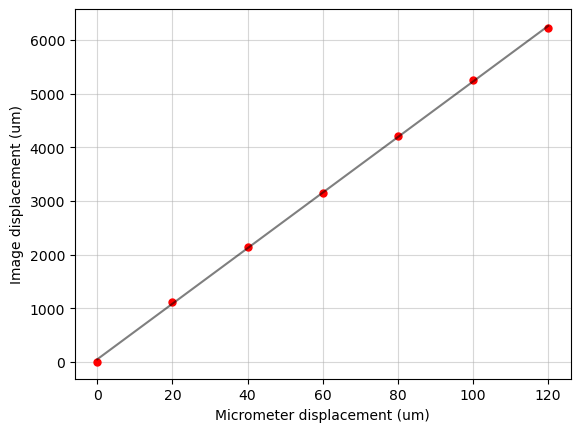

In [5]:
# magnification measurement

micrometer_screw_position = np.array([5.86, 5.88, 5.90, 5.92, 5.94, 5.96, 5.98]) # mm
x_loc = np.array([366, 271, 190, 115, 30, -42, -122]) # um
y_loc = np.array([2232, 1114, 100, -906, -1959, -2995, -3972]) # um

micrometer_screw_displacement = 1000 * (micrometer_screw_position - micrometer_screw_position[0]) # um
x_dis = x_loc - x_loc[0]
y_dis = y_loc - y_loc[0]
total_dis = np.sqrt(x_dis**2 + y_dis**2)

# fit line to model:
model = LinearModel()
params = model.make_params()
out = model.fit(total_dis, params, x = micrometer_screw_displacement)

print('Magnification: ')
print(out.params['slope'].value)

plt.plot(micrometer_screw_displacement, total_dis, '.', color = 'red', markersize = 10)
plt.xlabel('Micrometer displacement (um)')
plt.ylabel('Image displacement (um)')
plt.plot(micrometer_screw_displacement, out.best_fit, '-', label='best fit', color = 'black', alpha = 0.5)
plt.grid(alpha=0.5)
plt.show()


# <font size = 5>Microscope objective characterization: PSF</font>

In [5]:
# helper functions
def profile_gaussian_with_offset(x, amplitude, offset, Sx, Sy, x_center, y_center, theta):
    xx, yy = x
    x_prime =  np.cos(theta) * (xx-x_center) + np.sin(theta)*(yy-y_center)
    y_prime = -np.sin(theta) * (xx-x_center) + np.cos(theta)*(yy-y_center)
    profile_gaussian =  amplitude*np.exp(-x_prime**2/(2*Sx**2))*np.exp(-y_prime**2/(2*Sy**2)) + offset
    return profile_gaussian.ravel()

def find_center(data, show_fit = True):
    data = np.nan_to_num(data, nan = np.inf)
    y_size = np.shape(data)[0]
    x_size = np.shape(data)[1]
    x = np.linspace(0, x_size - 1, x_size)
    y = np.linspace(0, y_size - 1, y_size)
    X,Y = np.meshgrid(x,y)
    # generate initial guess
    amplitude_guess = np.max(data)
    offset_guess = 0
    Sx_guess = 5
    Sy_guess = 5
    x_center_guess = x_size//2
    y_center_guess = y_size//2
    theta_guess = 0
    # generate fit model:
    model = Model(profile_gaussian_with_offset)
    params = model.make_params(amplitude=amplitude_guess,
                               offset=offset_guess,
                               Sx=Sx_guess,
                               Sy = Sy_guess,
                               x_center = x_center_guess,
                               y_center = y_center_guess,
                               theta = theta_guess)
    lmfit_result = model.fit(data.ravel(), params, x= np.array((X, Y)), weights = None)
    report = lmfit_result.fit_report()
    # print(report)
    popt = lmfit_result.params
    # compute residuals
    data_fitted = profile_gaussian_with_offset((X,Y),
                                               amplitude = popt['amplitude'].value,
                                               offset = popt['offset'].value,
                                               Sx = popt['Sx'].value,
                                               Sy = popt['Sy'].value,
                                               x_center = popt['x_center'].value,
                                               y_center = popt['y_center'].value,
                                               theta = popt['theta'].value)
    data_fitted = data_fitted.reshape(y_size,x_size)
    residuals = data - data_fitted
    if show_fit:
        fig, ax = plt.subplots(1,4, figsize=(10,3))
        ax[0].contour(X, Y, data_fitted, 3, colors = 'white', linewidth = 0.1, alpha = 0.75)
        ax[0].pcolor(X, Y, data, cmap = 'plasma')
        ax[0].set_title(f'Sx = {popt["Sx"].value:.1f} px\n Sy = {popt["Sy"].value:.1f} px', fontsize = 12)
        ax[1].hist(residuals.ravel(), bins='auto', edgecolor='black', linewidth=0.1)
        ax[1].set_title(f'Histogram of residuals', fontsize = 12)
        ax[2].plot(x, data_fitted[y_size//2,:])
        ax[2].plot(x, data[y_size//2,:])
        ax[2].set_title('Cut along X at Y-center')
        ax[3].plot(y, data_fitted[:,x_size//2])
        ax[3].plot(y, data[:,x_size//2])
        ax[3].set_title('Cut along Y at X-center')
        plt.tight_layout()
        plt.show()
    return popt["x_center"].value, popt["y_center"].value

def radial_profile(data, center,  camera_magnification, imaging_magnification):
    y,x = np.indices((data.shape))
    r = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    return r.ravel() * camera_magnification * 1000 / imaging_magnification, data.ravel()

def radial_profile_with_binning(data, center, bins, camera_magnification, imaging_magnification):
    y,x = np.indices((data.shape))
    r = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    # now sort and bin
    s = np.argsort(r.ravel())
    sorted_r = r.ravel()[s] * camera_magnification * 1000 / imaging_magnification
    sorted_data = data.ravel()[s] # sorted by r
    r_binned_data, edges, _ = scipy.stats.binned_statistic(sorted_r, sorted_data, 'mean', bins=bins)
    r_binned = edges[:-1]
    return r_binned, r_binned_data/max(r_binned_data)

def ideal_psf(r, NA = 0.7, lam = 589):
    R = 0.61 * lam / NA # radius of first zero, lam in nm
    Rz = 1.2196698912665045
    u = np.pi * r / (R/Rz) # r in nm
    return (2 * jn(1, u) / u)**2

In [7]:
# single-image analysis
image_filename = '3.tiff'
image_file = '/Users/huanbui/Desktop/microscope_testing/20250305/FOV/' + image_filename
# dark_folder = '/Users/huanbui/Desktop/microscope_testing/20250130'
dark_file = '/Users/huanbui/Desktop/microscope_testing/20250305/dark/dark_0.tiff'
camera_magnification = 6.45 # um per pixel
imaging_magnification = 49
# crop to get a smaller image to work faster
roi_size = 40
bins = roi_size
# dark = None
# for dark_file in os.listdir(dark_folder):
#     dark = np.array(Image.open(dark_folder + '/' + dark_file), dtype = 'int64')
# dark = dark / len(os.listdir(dark_folder))
dark = np.array(Image.open(dark_file), dtype = 'int64')
im = np.array(Image.open(image_file), dtype = 'int64')
im = im - dark
x_center_guess, y_center_guess = np.unravel_index(im.argmax(), im.shape)
design_NA = 0.65
lam = 589 # 767

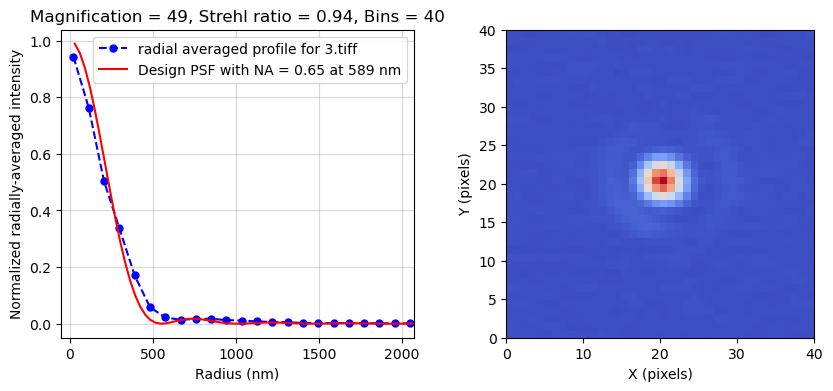

In [8]:
# run analysis
cropped = im[x_center_guess - int(roi_size/2):x_center_guess + int(roi_size/2), 
                y_center_guess - int(roi_size/2):y_center_guess + int(roi_size/2)]
# find center
x_center, y_center = find_center(cropped, show_fit=False)

# do radial average around centers
r_binned, r_binned_data = radial_profile_with_binning(cropped, 
                                                      [x_center, y_center], 
                                                      bins = bins, 
                                                      camera_magnification = camera_magnification, 
                                                      imaging_magnification = imaging_magnification)
fig, ax = plt.subplots(nrows = 1, ncols=2, figsize = (10,4))
r_psf = np.linspace(0,3000,100)
psf = ideal_psf(r_psf, NA = design_NA, lam = lam)
r_binned_data = np.nansum(ideal_psf(r_binned, NA = design_NA, lam = lam)) * r_binned_data/np.nansum(r_binned_data)

ax[0].plot(r_binned, r_binned_data, '.--', color = 'blue', markersize = 10, label = 'radial averaged profile for ' + image_filename)
ax[0].plot(r_psf, psf, color = 'red', label = f'Design PSF with NA = {design_NA} at {lam} nm')
ax[0].set_xlabel('Radius (nm)')
ax[0].set_ylabel('Normalized radially-averaged intensity')
ax[0].set_xlim([-50,2070])
ax[0].legend()
ax[0].grid(alpha = 0.5)
ax[0].set_title(f'Magnification = {imaging_magnification}, Strehl ratio = {r_binned_data[0]:.2f}, Bins = {bins}')

ax[1].pcolor(cropped, cmap = 'coolwarm')
ax[1].set_xlabel('X (pixels)')
ax[1].set_ylabel('Y (pixels)')
ax[1].axis('square')
plt.show()

In [8]:
# multi-image analysis setup
image_folder = '/Users/huanbui/Desktop/microscope_testing/20250305/FOV/'
dark_folder = '/Users/huanbui/Desktop/microscope_testing/20250305/dark/'
camera_magnification = 6.45 # um per pixel
imaging_magnification = 49
roi_size = 40
bins = roi_size
design_NA = 0.65
# generate ideal PSF
r_psf = np.linspace(0,3000,100)
psf = ideal_psf(r_psf, NA = design_NA, lam = 589)
# FOV_start, FOV_end = 24, 26

In [9]:
# run multi-image analysis
dark = None
for dark_file in os.listdir(dark_folder):
    dark = np.array(Image.open(dark_folder + '/' + dark_file), dtype = 'int64')
dark = dark / len(os.listdir(dark_folder)) # get average dark shot
strehl_ratios = np.array([])
# create img file list in ascending numerical order
img_files = os.listdir(image_folder)
file_names_with_numbers = [f for f in img_files if any(char.isdigit() for char in f)]
img_files = sorted(file_names_with_numbers, key=lambda f: int(''.join(filter(str.isdigit,f)))) 
r_FOV = np.array([])
data_FOV = np.array([])
for i in range(len(img_files)):
    # print(img_file)
    im = np.array(Image.open(image_folder + '/' + img_files[i]), dtype = 'int64')
    im = im - dark
    x_center_guess, y_center_guess = np.unravel_index(im.argmax(), im.shape)
    cropped = im[x_center_guess - int(roi_size/2):x_center_guess + int(roi_size/2), 
                 y_center_guess - int(roi_size/2):y_center_guess + int(roi_size/2)]
    x_center, y_center = find_center(cropped, show_fit=False)
    r_binned, r_binned_data = radial_profile_with_binning(cropped, [x_center, y_center], bins, camera_magnification, imaging_magnification)
    # normalize to ideal PSF:
    r_binned_data = np.nansum(ideal_psf(r_binned, NA = design_NA, lam = 589)) * r_binned_data/np.nansum(r_binned_data)
    # if FOV_start <= i <= FOV_end: 
    #     r, data = radial_profile(cropped, [x_center, y_center],  camera_magnification, imaging_magnification)
    #     r_FOV = np.append(r_FOV, r)
    #     data_FOV = np.append(data_FOV, data)        
    # compute Strehl ratio and add to list
    strehl_ratios = np.append(strehl_ratios, r_binned_data[0])

# # get data from FOV:
# s = np.argsort(r_FOV)
# sorted_r_FOV = r_FOV[s]
# sorted_data_FOV = data_FOV[s] # sorted by r
# r_binned_data_FOV, edges, _ = scipy.stats.binned_statistic(sorted_r_FOV, sorted_data_FOV, 'mean', bins=np.sqrt(len(r_FOV)))
# r_binned_FOV = edges[:-1]
# r_binned_data_FOV = np.nansum(ideal_psf(r_binned_FOV, NA = design_NA, lam = 589)) * r_binned_data_FOV/np.nansum(r_binned_data_FOV)


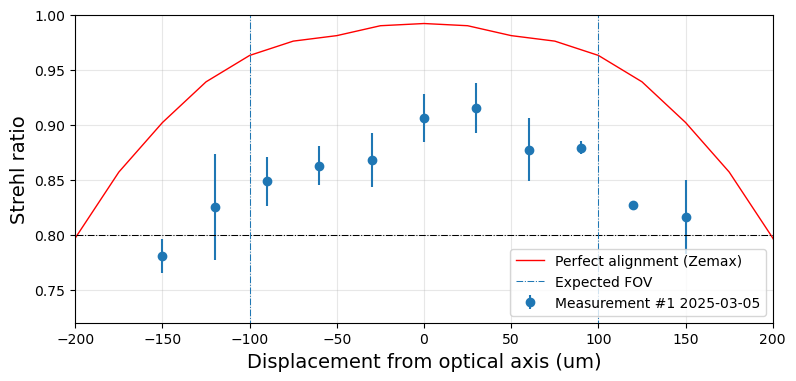

In [21]:
# plotting FOV measurement:
design_FOV_displacement = np.array([0,25,-25,50,-50,75,-75,100,-100,125,-125,150,-150,175,-175,200,-200,225,-225,250,-250])
design_FOV_Strehl  = np.array([0.992,0.990,0.990,0.981,0.981,0.976,0.976,0.963,0.963,0.939,0.939,0.902,0.902,0.857,0.857,0.797,0.797,0.719,0.719,0.626, 0.626])
design_ind = np.argsort(design_FOV_displacement)

tilted_FOV_displacement = np.array([0,25,-25,50,-50,75,-75,100,-100,125,-125,150,-150,175,-175,200,-200,225,-225,250,-250]) + 100
tilted_FOV_Strehl = np.array([0.833,0.817,0.850,0.799,0.863,0.777,0.871,0.750,0.872,0.718,0.870,0.683,0.856,0.639,0.826,0.585,0.780,0.523,0.716,0.457,0.635])
tilted_ind = np.argsort(tilted_FOV_displacement)

# FOV 1 2025-01-29 bins = 20
FOV_1_displacement = np.array([0,30,60,90,120,-30,-60,-90,-120])
FOV_1_Strehl = np.array([0.82, 0.84, 0.78,0.79,0.68,0.81,0.84,0.79,0.68])
FOV_1_ind = np.argsort(FOV_1_displacement)

# FOV 2 2025-01-29 bins = 20
FOV_2_displacement = np.array([0,30,60,90,120,-30,-60,-90,-120,-150])
FOV_2_Strehl = np.array([0.84,0.78,0.78,0.81,0.72,0.85,0.80,0.83,0.72,0.70])
FOV_2_ind = np.argsort(FOV_2_displacement)

# FOV 1 2025-01-30
dis = np.array([220,220,220,250,250,250,280,280,280,310,310,310,340,340,340,
                370,370,370,400,400,400,220,220,220,190,190,190,160,160,160,
                130,130,130,100,100,100,70,70,70,40,40,40,
                10,10,10,-20,-20,-20,220,220,220]) - 190

# # FOV 1 2025-01-29
dis = np.array([260,260,260,280,280,280,300,300,300,220,220,220,240,240,240,200,200,200,170,170,170,
                140,140,140,110,110,110,80,80,80,320,320,320,350,350,350,380,380,380,410,410,410,440,440,440]) - 240

# FOV 2025-03-05
dis = np.array([120,120,120,150,150,150,180,180,180,210,210,210,240,240,240,270,270,270,90,90,90,60,60,60,30,30,30,0,0,0,-30,-30,-30])-120

# plotting
plt.figure(figsize=(9, 4))
plt.plot(design_FOV_displacement[design_ind], design_FOV_Strehl[design_ind], '-', label = 'Perfect alignment (Zemax)', color = 'red', linewidth=1)
# plt.plot(tilted_FOV_displacement[tilted_ind], tilted_FOV_Strehl[tilted_ind], '-', label = 'With 0.03-deg tilt (Zemax)', color = 'green', linewidth=0.5)
# plt.plot(FOV_1_displacement[FOV_1_ind], FOV_1_Strehl[FOV_1_ind], 's', label = 'Measurement #1 2025-01-29', color = 'blue', markersize = 7)
# plt.plot(FOV_2_displacement[FOV_2_ind], FOV_2_Strehl[FOV_2_ind], 'o', label = 'Measurement #2 2025-01-29', color = 'green', markersize = 7)
fancy_plot(dis, strehl_ratios, 'o', label = 'Measurement #1 2025-03-05', markersize = 6)

plt.hlines(y=0.8, xmin = -400, xmax = 400, linestyle = '-.', linewidth = 0.75, color = 'black')
plt.vlines(x=[-100,100], ymin = 0, ymax = 1.1, linestyle = '-.', linewidth = 0.75, label = 'Expected FOV')

# plt.title(f'Objective #3, Strehl ratio wrt {design_NA} NA PSF', fontsize = 14)
plt.ylabel('Strehl ratio', fontsize = 14)
plt.xlabel('Displacement from optical axis (um)', fontsize = 14)
plt.legend(fontsize = 10)
plt.grid(alpha=0.3)
plt.ylim([0.72, 1.00])
plt.xlim([-200, 200])
plt.show()

# <font size = 5>Wavefront expansion analysis</font>

Interpreting the "pupil_radius_in_pixel" variable: This basically tells us the NA. To convert this quantity to NA, we first have to find the magnification (mm per pixel) in the pupil plane. The magnification in the psf plane is known. It is simply the camera magnification. This quantity is related to the pupil plane magnification via the relation:
$$ M_\text{psf plane} = \text{Camera um per pixel} = \frac{\lambda \times f_\text{tube lens}}{S_\text{pupil plane}} = \frac{\lambda \times f_\text{tube lens}}{S_\text{pupil plane in pixels} \times M_\text{pupil plane}} $$ 
where $S$ is the size of the pupil plane. Since we know the size of the pupil plane in pixels, the pupil plane magnification (mm per pixel) can be found. The NA then follows:
$$ NA = \frac{\text{Pupil radius in pixels} \times \text{Pupil plane mm per pixel}}{f_\text{obj}} = \frac{\text{Pupil radius in pixels} \times \text{Pupil plane mm per pixel} \times \text{Imaging magnification}}{f_\text{tube lens}}  $$
We see that the dependence on the tube lens and objective focal lengths drop out. We get the following formula for the NA:
$$ NA = \frac{\text{Pupil radius in pixels } \times \lambda \times \text{Imaging magnification}}{\text{ROI size} \times \text{Camera magnification} } $$

In [799]:
# wavefront expansion Zernike coef fit
def Zernike_cartesian(x, Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44):
    u,v = x
    r = np.sqrt(u**2 + v**2) 
    ZW = 0
    ZW += Z00  * 1 # piston, just constant phase, no need to add
    ZW += Z11  * 2*u # X-tilt
    ZW += Zm11 * 2*v # Y-tilt
    ZW += Z02  * np.sqrt(3)*(2*r**2-1) # defocus
    ZW += Zm22 * 2*np.sqrt(6)*u*v # oblique astigmatism
    ZW += Z22  * np.sqrt(6)*(u**2-v**2) # vertical astigmatism
    ZW += Zm13 * np.sqrt(8)*v*(3*r**2-2) # vertical coma
    ZW += Z13  * np.sqrt(8)*u*(3*r**2-2) # horizontal coma
    ZW += Zm33 * np.sqrt(8)*v*(3*u**2-v**2) # vertical trefoil
    ZW += Z33  * np.sqrt(8)*u*(u**2-3*v**2) # oblique trefoil
    ZW += Zm44 * 4*np.sqrt(10)*u*v*(u**2-v**2) # oblique quadrafoil 
    ZW += Zm24 * 2*np.sqrt(10)*u*v*(4*r**2-3) # oblique secondary astigmatism
    ZW += Z04  * np.sqrt(5)*(6*r**4-6*r**2+1)  # primary spherical
    ZW += Z24  * np.sqrt(10)*(u**2-v**2)*(4*r**2-3) # vertical secondary astigmatism
    ZW += Z44  * np.sqrt(10)*(r**4-8*u**2*v**2) # vertical quadrafoil 
    return ZW

def pupil(x, pupil_radius_in_pixels):
    u,v = x
    return np.heaviside(pupil_radius_in_pixels**2 - u**2 - v**2, 1)

def aberration(x, pupil_radius_in_pixels, Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44):
    [u,v] = x
    u = u/pupil_radius_in_pixels
    v = v/pupil_radius_in_pixels
    return Zernike_cartesian([u,v],Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44)

def complex_pupil(x, pupil_radius_in_pixels, Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44):
    p = pupil(x, pupil_radius_in_pixels)
    A = aberration(x,pupil_radius_in_pixels, Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44)
    return p * np.exp(1j * 2*np.pi * A)

def psf_profile(x, pupil_radius_in_pixels, amplitude, offset, theta, Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44):
    [u,v] = x
    up = (np.cos(theta) * u + np.sin(theta)*v)
    vp = (-np.sin(theta) * u + np.cos(theta)*v)
    complex_p = complex_pupil([up,vp], pupil_radius_in_pixels, Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44)
    PSF = fftshift(fft2(complex_p))
    PSF = (np.abs(PSF))**2 
    PSF = PSF/np.max(PSF) #normalizing the PSF
    return amplitude * PSF + offset

# perform wavefront expansion to get zernike's coefs
def fit_zernike(v_nm, data):
    data = np.nan_to_num(data, nan = np.inf)
    X,Y = v_nm
    # generate fit model with initial guesses
    model = Model(psf_profile)
    pupil_radius_in_pixels = round(0.58 * roi_size * 6.45 / (589 * 1e-3 * 50))
    params = model.make_params(amplitude = np.max(data),
                               offset = 0,
                               theta = dict(value=0, min=0, max = 1),
                               pupil_radius_in_pixels = dict(value = pupil_radius_in_pixels, min = 0, max = 100), # just a guess
                               Z00 =0,
                               Zm11 =dict(value=0, min=-0.2, max = 0.2), 
                               Z11  =dict(value=0, min=-0.2, max = 0.2),
                               Zm22 =dict(value=0, min=-0.2, max = 0.2), 
                               Z02  =dict(value=0, min=-0.3, max = 0.3),
                               Z22  =dict(value=0, min=-0.2, max = 0.2),
                               Zm33 =dict(value=0, min=-0.2, max = 0.2),
                               Zm13 =dict(value=0, min=-0.2, max = 0.2),
                               Z13  =dict(value=0, min=-0.2, max = 0.2),
                               Z33  =dict(value=0, min=-0.2, max = 0.2),
                               Zm44 =0,Zm24=0,
                               Z04  =dict(value=0, min=-0.2, max = 0.2),
                               Z24  =0,Z44=0)
    # params['Z11'].vary = False
    # params['Zm11'].vary = False
    params['Z00'].vary = False
    params['Zm44'].vary = False
    params['Z44'].vary = False
    params['Z24'].vary = False
    params['Zm24'].vary = False
    # params['Zm33'].vary = False
    # params['Z33'].vary = False
    params['theta'].vary = False
    # params['pupil_radius_in_pixels'].vary = False
    lmfit_result = model.fit(data, params, x= np.array((X, Y)), weights = None) #, method = 'powell')

    # fitted data:
    data_fitted = psf_profile((X,Y),
                            pupil_radius_in_pixels = lmfit_result.params['pupil_radius_in_pixels'].value,
                            amplitude = lmfit_result.params['amplitude'].value,
                            offset = lmfit_result.params['offset'].value,
                            theta = lmfit_result.params['theta'].value, 
                            Z00  = lmfit_result.params['Z00'].value,
                            Zm11 = lmfit_result.params['Zm11'].value,
                            Z11  = lmfit_result.params['Z11'].value,
                            Zm22 = lmfit_result.params['Zm22'].value,
                            Z02  = lmfit_result.params['Z02'].value,
                            Z22  = lmfit_result.params['Z22'].value,
                            Zm33 = lmfit_result.params['Zm33'].value,
                            Zm13 = lmfit_result.params['Zm13'].value,
                            Z13  = lmfit_result.params['Z13'].value,
                            Z33  = lmfit_result.params['Z33'].value,
                            Zm44 = lmfit_result.params['Zm44'].value,
                            Zm24 = lmfit_result.params['Zm24'].value,
                            Z04  = lmfit_result.params['Z02'].value,
                            Z24  = lmfit_result.params['Z24'].value,
                            Z44  = lmfit_result.params['Z44'].value)
    data_fitted = data_fitted.reshape(data.shape[0],data.shape[1])
    return lmfit_result, data_fitted

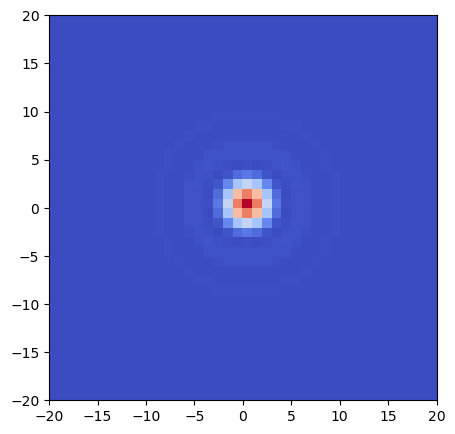

In [798]:
# random testing
roi_size = 200
NA = 0.65
lam = 589
camera_um_per_px = 6.45
imaging_magnification = 49.7
viewing_roi_size = 40
pupil_radius_in_pixels = round(NA * roi_size * camera_um_per_px / (lam * 1e-3 * imaging_magnification))
psf_plane_um_per_px = camera_um_per_px

# underlying pixel grid
x_pix = np.linspace(-roi_size/2, roi_size/2, roi_size)
y_pix = np.linspace(-roi_size/2, roi_size/2, roi_size)
[X_pix,Y_pix] = np.meshgrid(x_pix,y_pix)

Z00 = 0
Zm11,Z11 = 0,0
Zm22,Z02,Z22 = 0.0,0.02, 0.0
Zm33,Zm13,Z13,Z33 = 0,0.0,0.0,0
Zm44,Zm24,Z04,Z24,Z44 = 0,0,0.00,0,0

p = pupil([X_pix, Y_pix], pupil_radius_in_pixels)
a = aberration([X_pix, Y_pix], pupil_radius_in_pixels, Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44)
c = complex_pupil([X_pix,Y_pix], pupil_radius_in_pixels, Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44)

psf = psf_profile([X_pix,Y_pix], pupil_radius_in_pixels, 1, 0, 0, Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44)
# psf_065 = psf_profile([X_pix,Y_pix], pupil_radius_in_pixels, 1, 0, 0, Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44)

plt.figure(figsize = (5,5))
plt.pcolor(X_pix, Y_pix, psf, cmap = 'coolwarm')
plt.xlim([-viewing_roi_size//2, viewing_roi_size//2])
plt.ylim([-viewing_roi_size//2, viewing_roi_size//2])
# plt.axis('square')
plt.show()

In [897]:
# single-image analysis
image_filename = '8.tiff'
image_file = '/Users/huanbui/Desktop/microscope_testing/20250305/images/' + image_filename
dark_file = '/Users/huanbui/Desktop/microscope_testing/20250305/dark/dark_0.tiff'
upscale_factor = 1
roi_size = 200 * upscale_factor

In [898]:
# do fit
lam = 589
camera_magnification = 6.45 * upscale_factor
imaging_magnification = 50.0
viewing_roi_size = 40 * upscale_factor 
# crop to get a smaller image to work faster
dark = Image.open(dark_file)
im = Image.open(image_file)

# upscale 
im = np.array(im.resize(size=(im.size[0]*upscale_factor, im.size[1]*upscale_factor), resample= Image.NEAREST), dtype = 'int64')
dark = np.array(dark.resize(size=(dark.size[0]*upscale_factor, dark.size[0]*upscale_factor), resample= Image.NEAREST), dtype = 'int64')
im = im - dark

# poor man's center finding 
x_center_guess, y_center_guess = np.unravel_index(im.argmax(), im.shape)

# re-crop so that feature is as centered as possible
centered_cropped = im[round(x_center_guess - roi_size/2) : round(x_center_guess + roi_size/2), 
                      round(y_center_guess - roi_size/2) : round(y_center_guess + roi_size/2)]
# make space of underlying pixel grid
x_pix = np.linspace(-roi_size/2, roi_size/2, roi_size)
y_pix = np.linspace(-roi_size/2, roi_size/2, roi_size)
[X_pix,Y_pix] = np.meshgrid(x_pix,y_pix)

# do fit
res, data_fitted = fit_zernike([X_pix, Y_pix], centered_cropped)
# normalize to find Strehl ratio:
data_fitted /= np.max(data_fitted)
centered_cropped = np.nansum(data_fitted) * centered_cropped / np.nansum(centered_cropped)
# get NA and Strehl ratio
NA_from_fit = (res.values['pupil_radius_in_pixels'] * lam * 1e-3 * imaging_magnification) / (roi_size * camera_magnification)
Strehl_from_fit = np.max(centered_cropped) / np.max(data_fitted)

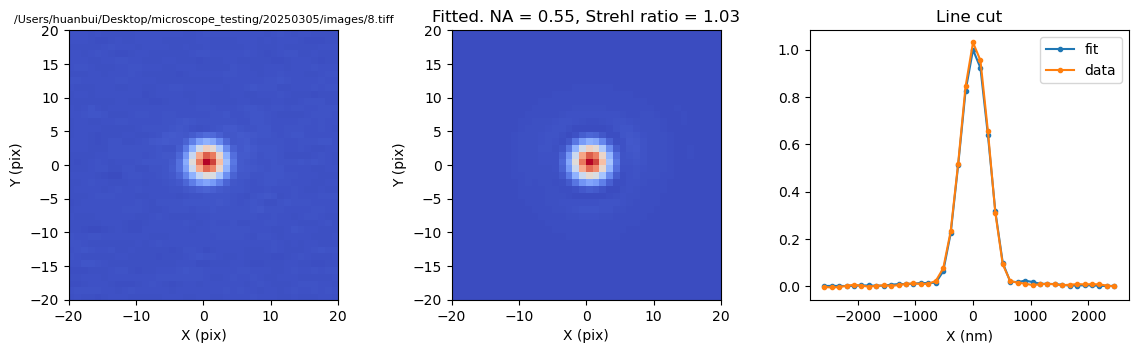

{'pupil_radius_in_pixels': np.float64(24.256320551715515),
 'amplitude': np.float64(53789.86799054249),
 'offset': np.float64(20.40352322656723),
 'theta': 0,
 'Z00': 0.0,
 'Zm11': np.float64(0.0038602857332719898),
 'Z11': np.float64(0.013305473157197267),
 'Zm22': np.float64(0.003257337569521873),
 'Z02': np.float64(0.04195248674501484),
 'Z22': np.float64(0.016807024050194797),
 'Zm33': np.float64(0.008747118108045099),
 'Zm13': np.float64(0.0020261406826328765),
 'Z13': np.float64(0.0052771126790194245),
 'Z33': np.float64(0.0015882226203513261),
 'Zm44': 0.0,
 'Zm24': 0.0,
 'Z04': np.float64(0.026128938495948384),
 'Z24': 0.0,
 'Z44': 0.0}

In [899]:
# plot results
fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (14, 3.5))
ax[0].pcolor(X_pix, Y_pix, centered_cropped, cmap = 'coolwarm')
ax[0].axis('square')
ax[0].set_xlim([-viewing_roi_size/2, viewing_roi_size/2])
ax[0].set_ylim([-viewing_roi_size/2, viewing_roi_size/2])
ax[0].set_xlabel('X (pix)')
ax[0].set_ylabel('Y (pix)')
ax[0].set_title(f'{image_file}', fontsize = 8)

ax[1].pcolor(X_pix, Y_pix, data_fitted, cmap = 'coolwarm')
ax[1].axis('square')
ax[1].set_xlim([-viewing_roi_size/2, viewing_roi_size/2])
ax[1].set_ylim([-viewing_roi_size/2, viewing_roi_size/2])
ax[1].set_xlabel('X (pix)')
ax[1].set_ylabel('Y (pix)')
ax[1].set_title(f'Fitted. NA = {NA_from_fit:.2f}, Strehl ratio = {Strehl_from_fit:.2f}')

r_plot = np.arange(-viewing_roi_size//2, viewing_roi_size//2) * camera_magnification * 1e3 / imaging_magnification # um
ax[2].plot(r_plot, data_fitted[data_fitted.shape[0]//2, data_fitted.shape[0]//2-viewing_roi_size//2:data_fitted.shape[0]//2+viewing_roi_size//2], '.-', label = 'fit')
ax[2].plot(r_plot, centered_cropped[data_fitted.shape[0]//2, data_fitted.shape[0]//2-viewing_roi_size//2:data_fitted.shape[0]//2+viewing_roi_size//2], '.-', label = 'data')
ax[2].set_title('Line cut')
ax[2].set_xlabel('X (nm)')
ax[2].legend()
plt.show()

# show best values
res.best_values

# <font size = 5>Generalized Lattice Reconstruction</font>

In [29]:
# numba functions
@njit(nopython=True, cache=True, parallel=True, fastmath = True)
def get_bin_edges(a, bins):
    bin_edges = np.zeros((bins+1,), dtype=np.float64)
    a_min = a.min()
    a_max = a.max()
    delta = (a_max - a_min) / bins
    for i in range(bin_edges.shape[0]):
        bin_edges[i] = a_min + i * delta

    bin_edges[-1] = a_max  # Avoid roundoff error on last point
    return bin_edges

@njit(nopython=True, cache=True, fastmath=True)
def compute_bin(x, bin_edges):
    # assuming uniform bins for now
    n = bin_edges.shape[0] - 1
    a_min = bin_edges[0]
    a_max = bin_edges[-1]

    # special case to mirror NumPy behavior for last bin
    if x == a_max:
        return n - 1 # a_max always in last bin

    bin = int(n * (x - a_min) / (a_max - a_min))

    if bin < 0 or bin >= n:
        return None
    else:
        return bin

@njit(nopython=True, cache=True, parallel=True, fastmath=True)
def numba_histogram(a, bins):
    hist = np.zeros((bins,), dtype=np.intp)
    bin_edges = get_bin_edges(a, bins)

    for x in a.flat:
        bin = compute_bin(x, bin_edges)
        if bin is not None:
            hist[int(bin)] += 1
    bin_edges = bin_edges[:-1]
    return hist, bin_edges

@njit(nopython=True, cache=True, fastmath = True)
# double-gaussian model
def double_gaussian(x, mu1, mu2, amp1, amp2, sigma1, sigma2):
    return amp1 * np.exp(-0.5 * ((x - mu1)/sigma1)**2)  + amp2 * np.exp(-0.5 * ((x - mu2)/sigma2)**2)

@njit(nopython=True, cache=True, parallel = True, fastmath = True)
def numba_resize(image, output_shape):
    input_shape = image.shape
    output_image = np.zeros(output_shape, dtype=image.dtype)
    
    row_scale = input_shape[0] / output_shape[0]
    col_scale = input_shape[1] / output_shape[1]
    
    for i in range(output_shape[0]):
        for j in range(output_shape[1]):
            src_row = i * row_scale
            src_col = j * col_scale
            
            row_floor = int(np.floor(src_row))
            col_floor = int(np.floor(src_col))
            row_ceil = min(row_floor + 1, input_shape[0] - 1)
            col_ceil = min(col_floor + 1, input_shape[1] - 1)
            
            row_weight = src_row - row_floor
            col_weight = src_col - col_floor
            
            top_left = image[row_floor, col_floor]
            top_right = image[row_floor, col_ceil]
            bottom_left = image[row_ceil, col_floor]
            bottom_right = image[row_ceil, col_ceil]
            
            top = top_left + (top_right - top_left) * col_weight
            bottom = bottom_left + (bottom_right - bottom_left) * col_weight
            output_image[i, j] = top + (bottom - top) * row_weight
    
    return output_image

# compute differences between entries in a 1D array
@njit(nopython=True, cache = True, parallel = True, fastmath=True)
def compute_differences(arr):
    n = len(arr.astype(np.float32))
    differences = np.empty((n * (n - 1)) // 2, dtype=arr.dtype)
    index = 0
    for i in range(n):
        for j in range(i + 1, n):
            differences[index] = arr[j] - arr[i]
            index += 1
    return np.abs(differences)

In [3299]:
# helper functions
# draw grid to help visualize lattice
def draw_grid(image, line_space=12):
    new_image = image.copy()
    new_image[::line_space, :] = np.max(image)
    new_image[:, ::line_space] = np.max(image)
    return new_image

# apply rotation to local peaks
def rotate_peak(peak, theta, center_coords, mode = 'common'):
    peak = peak - center_coords
    if mode == 'common':
        rotation_matrix = np.array( [[ np.cos(theta * np.pi/180), np.sin(theta * np.pi/180)], 
                                     [-np.sin(theta * np.pi/180), np.cos(theta * np.pi/180)]])
        
    elif mode == 'relative':
        rotation_matrix = np.array( [[1, -np.sin(theta * np.pi/180)],
                                     [0, 1]])
    else:
        raise ValueError("Invalid rotation mode. Use 'common' or 'relative'.")
    
    return np.matmul(peak, rotation_matrix) + center_coords

# rotate image using OpenCV
def rotate_image_openCV(image, theta, mode='common'):
    rows, cols = image.shape[:2]
    center_x, center_y = cols // 2, rows // 2
    theta_rad = np.deg2rad(theta)
    if mode == 'common':
        affine_matrix = np.array([
                        [np.cos(theta_rad), -np.sin(theta_rad), 0],
                        [np.sin(theta_rad), np.cos(theta_rad), 0]
                    ] )
    elif mode == 'relative':
        affine_matrix = np.array([
                        [1, np.sin(theta_rad), 0],
                        [0, 1, 0]
                    ])
    else:
        raise ValueError("Invalid rotation mode. Use 'common' or 'relative'.")
    affine_matrix[0, 2] += center_x - (affine_matrix[0, 0] * center_x + affine_matrix[0, 1] * center_y)
    affine_matrix[1, 2] += center_y - (affine_matrix[1, 0] * center_x + affine_matrix[1, 1] * center_y)
    return cv2.warpAffine(image, affine_matrix, (cols, rows))

# generate gaussian-distributed atoms in lattice
def generate_gaussian_matrix(size, mean, std_dev, filling_fraction):
    x = np.linspace(-1, 1, size)
    y = np.linspace(-1, 1, size)
    X, Y = np.meshgrid(x, y)
    gaussian = np.exp(-((X - mean[0])**2 + (Y - mean[1])**2) / (2 * std_dev**2))
    matrix = np.random.rand(size, size) < gaussian * filling_fraction
    return matrix.astype(int)

# generate ideal PSF
def psf_2d(x, y, NA = 0.7, lam = 589):
    R = 0.61 * lam / NA # radius of first zero, lam in nm
    Rz = 1.2196698912665045
    u = np.pi * np.sqrt(x**2 + y**2) / (R/Rz) # r in nm
    return ((2 * jn(1, u) / u)**2)

def dark_BG(mu, sigma, size):
    return np.reshape(halfnorm.rvs(loc = mu, scale = sigma, size=size**2), (size, size) )

def FT_no_DC(signal, bin_size = 1):
    ft = pyfftw.interfaces.numpy_fft.fft(signal)
    abs_ft = np.abs(ft)[7:round(len(signal)//2)] # skip the DC part
    freqs  = np.fft.fftfreq(len(signal), d=bin_size)[7:round(len(signal)//2)]
    return abs_ft/abs_ft[0], freqs # normalize relative to the lowest frequency amplitude

# get lattice spacing from FT
def get_lattice_spacing(freqs, data, low_cutoff, high_cutoff):
    masked_data = np.ma.masked_where((freqs < low_cutoff) | (freqs > high_cutoff), data, copy = True)
    ind = np.argmax(masked_data)
    return 1/freqs[ind], data[ind] # spacing and peak height

# help with finding lattice spacing and angles... around 20-40 ms per call
def from_peaks_to_lattice_info(peaks, super_sample_factor, camera_pixel_per_site, image_shape):
    image_shape /= super_sample_factor
    # compute differences between peaks: takes around 15 ms
    diff_px, diff_py = compute_differences(peaks[:,0]) / super_sample_factor, compute_differences(peaks[:,1]) / super_sample_factor

    # generate histograms, takes around 15 ms
    diff_px_counts, diff_px_binned = numba_histogram(diff_px, bins = round(5*np.sqrt(len(diff_px))))
    diff_py_counts, diff_py_binned = numba_histogram(diff_py, bins = round(5*np.sqrt(len(diff_py))))

    # cut off extreme differences
    diff_px_counts = diff_px_counts[diff_px_binned < image_shape[0]/1.5]
    diff_px_binned = diff_px_binned[diff_px_binned < image_shape[0]/1.5]
    diff_py_counts = diff_py_counts[diff_py_binned < image_shape[1]/1.5]
    diff_py_binned = diff_py_binned[diff_py_binned < image_shape[1]/1.5]

    # compute FFT of the differences
    fdiff_px_counts, freq_diff_px_counts = FT_no_DC(signal = diff_px_counts, bin_size = diff_px_binned[1] - diff_px_binned[0]) 
    fdiff_px_counts = fdiff_px_counts[freq_diff_px_counts < 0.5]
    freq_diff_px_counts = freq_diff_px_counts[freq_diff_px_counts < 0.5]
    fdiff_py_counts, freq_diff_py_counts = FT_no_DC(signal = diff_py_counts, bin_size = diff_py_binned[1] - diff_py_binned[0]) 
    fdiff_py_counts = fdiff_py_counts[freq_diff_py_counts < 0.5]
    freq_diff_py_counts = freq_diff_py_counts[freq_diff_py_counts < 0.5]   

    # Find the most prominent peak. Typically we don't expect features with 1/4px >= spatial frequencies >= 1/(psf_px_per_lattice constant + 2)
    low_cutoff, high_cutoff = 1/(camera_pixel_per_site + 0.4), 1/(camera_pixel_per_site-0.4)
    
    # compute lattice spacing and FFT peak height
    lattice_spacing_x, fft_strength_x = get_lattice_spacing(freq_diff_px_counts, fdiff_px_counts, low_cutoff, high_cutoff)
    lattice_spacing_y, fft_strength_y = get_lattice_spacing(freq_diff_py_counts, fdiff_py_counts, low_cutoff, high_cutoff)

    spacing_dict = {}
    spacing_dict['diff_px_counts'] = diff_px_counts
    spacing_dict['diff_px_binned'] = diff_px_binned
    spacing_dict['diff_py_counts'] = diff_py_counts
    spacing_dict['diff_py_binned'] = diff_py_binned
    spacing_dict['freq_diff_px_counts'] = freq_diff_px_counts
    spacing_dict['fdiff_px_counts'] = fdiff_px_counts
    spacing_dict['freq_diff_py_counts'] = freq_diff_py_counts
    spacing_dict['fdiff_py_counts'] = fdiff_py_counts
    spacing_dict['lattice_spacing_x'] = lattice_spacing_x
    spacing_dict['lattice_spacing_y'] = lattice_spacing_y
    spacing_dict['fft_strength_x'] = fft_strength_x
    spacing_dict['fft_strength_y'] = fft_strength_y 

    return spacing_dict

# find best rotation of image:
def find_lattice_spacing_and_angles(image, camera_pixel_per_site, 
                                    theta_common_guess = 0, theta_rel_guess = 0, angle_search_window = 2, plotting = False, minmass = 5):
    
    # super-sample first:
    super_sample_factor = 5
    # image = numba_resize(image, (image.shape[0]*super_sample_factor, image.shape[1]*super_sample_factor))
    image = cv2.resize(image, (image.shape[1]*super_sample_factor, image.shape[0]*super_sample_factor), interpolation = cv2.INTER_CUBIC)

    # find peaks using trackpy_locate:
    peaks = tp.locate(image/image.max(), 
                      diameter = round(super_sample_factor*camera_pixel_per_site/2)*2 + 1, 
                      minmass = minmass,
                      separation = round(super_sample_factor*camera_pixel_per_site/2)*2 + 1,
                      maxsize = round(super_sample_factor*camera_pixel_per_site/2)*2 + 1)
    
    peaks = np.column_stack((peaks['y'], peaks['x']))
    
    # generate guesses for lattice angle and overall rotation
    theta_common_guesses = np.linspace(theta_common_guess - angle_search_window, theta_common_guess + angle_search_window, 100, dtype = np.float32)
    theta_rel_guesses = np.linspace(theta_rel_guess - angle_search_window, theta_rel_guess + angle_search_window, 100, dtype = np.float32)

    best_theta_common, best_theta_rel = 0,0

    # optimize by rotating. To reduce search space, optimize x first, then y
    rows, cols = image.shape[:2]
    center_coords = np.array([cols // 2, rows // 2])

    # finds the overall lattice rotation angle
    with tqdm_joblib(tqdm(desc="Finding overall lattice rotation", total = len(theta_common_guesses))) as progress_bar:
        spacing_dict_list = Parallel(n_jobs=-2)(delayed(from_peaks_to_lattice_info)(rotate_peak(peaks, theta_common, center_coords, mode = 'common'), 
                                                                                    super_sample_factor, 
                                                                                    camera_pixel_per_site, 
                                                                                    np.array(image.shape, dtype = 'float') )
                                                 for theta_common in theta_common_guesses)
    
    # get the spacing dict with the largest fft_strength_x:
    spacing_dict = max(spacing_dict_list, key=lambda d: d.get('fft_strength_x', float('-inf')))
    best_theta_common = theta_common_guesses[np.argmax([d['fft_strength_x'] for d in spacing_dict_list])]
    new_peaks = rotate_peak(peaks, best_theta_common, center_coords, mode = 'common')

    # finds the relative lattice angle
    with tqdm_joblib(tqdm(desc="Finding relative lattice angle", total = len(theta_rel_guesses))) as progress_bar:
        spacing_dict_list = Parallel(n_jobs=-2)(delayed(from_peaks_to_lattice_info)(rotate_peak(new_peaks, theta_rel, center_coords, mode='relative'), 
                                                                                    super_sample_factor, 
                                                                                    camera_pixel_per_site, 
                                                                                    np.array(image.shape, dtype = 'float')) 
                                                 for theta_rel in theta_rel_guesses)
    # get the spacing dict with the largest fft_strength_y:
    spacing_dict = max(spacing_dict_list, key=lambda d: d.get('fft_strength_y', float('-inf')))
    best_theta_rel = theta_rel_guesses[np.argmax([d['fft_strength_y'] for d in spacing_dict_list])]
    new_peaks = rotate_peak(new_peaks, best_theta_rel, center_coords, mode = 'relative')
    
    # rectify image
    rectified_image_upscaled = rotate_image_openCV(image, -best_theta_common, mode='common')
    rectified_image_upscaled = rotate_image_openCV(rectified_image_upscaled, -best_theta_rel, mode='relative')

    # downsample:
    # rectified_image = numba_resize(rectified_image_upscaled, (rectified_image_upscaled.shape[0]//super_sample_factor, 
    #                                                           rectified_image_upscaled.shape[1]//super_sample_factor))
    
    rectified_image = cv2.resize(rectified_image_upscaled, (rectified_image_upscaled.shape[1]//super_sample_factor, 
                                                            rectified_image_upscaled.shape[0]//super_sample_factor), interpolation = cv2.INTER_CUBIC)

    # plot super-sampled images with local peaks:
    if plotting:
        fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8, 4))
        ax[0].imshow(image, cmap = 'afmhot')
        ax[0].scatter(peaks[:,1], peaks[:,0], color = 'cyan', s = 2)
        ax[0].set_title('Original image with local peaks')
        # superimpose grid onto rectified image:
        ax[1].scatter(new_peaks[:,1], new_peaks[:,0], color = 'cyan', s = 2)
        ax[1].imshow(rectified_image_upscaled, cmap = 'afmhot')
        ax[1].imshow(draw_grid(rectified_image_upscaled, line_space = round(camera_pixel_per_site*super_sample_factor)), cmap = 'afmhot', alpha = 0.5)
        plt.show()

    return [best_theta_common, best_theta_rel], spacing_dict, rectified_image

# Wiener deconvolution
def wiener(camera_image, conj_F_psf, abs_F_psf_squared, eps):   

    # perform FFT using PyFFTW for speeeeeed
    a = pyfftw.empty_aligned((camera_image.shape[0],camera_image.shape[1]), dtype='complex64') 
    b = pyfftw.empty_aligned((a.shape[0],a.shape[1]), dtype='complex64') 
    a[...] = camera_image
    fft_object_FI = pyfftw.FFTW(a, b, axes=(0,1), direction = 'FFTW_FORWARD', flags = ['FFTW_DESTROY_INPUT'])

    c = pyfftw.empty_aligned((camera_image.shape[0],camera_image.shape[1]), dtype='complex64') 
    d = pyfftw.empty_aligned((c.shape[0],c.shape[1]),  dtype='complex64')
    c[...] = fft_object_FI() * conj_F_psf / (abs_F_psf_squared + eps)
    fft_object_w = pyfftw.FFTW(c, d, axes=(0,1), direction = 'FFTW_BACKWARD',  flags = ['FFTW_DESTROY_INPUT'])

    return np.abs(ifftshift(fft_object_w()))

# find the lattice phase and crop so that image dimensions are n * lattice spacing in pixels
def find_lattice_phase_and_crop(image, lattice_spacing_x, lattice_spacing_y, phase_finding_mode='fast'):
    best_x, best_y = 0,0

    if phase_finding_mode == 'fast':
        step = 2
    elif phase_finding_mode == 'slow':
        step = 1
    else:
        return None
        
    # maximize contrast in x first, then y --> O(lx+ly) problem instead of O(lx*ly)
    binned_and_raveled_list = np.array([cv2.resize(image[i:,:], 
                                                   (round(image[i:,:].shape[1]/lattice_spacing_x), round(image[i:,:].shape[0]/lattice_spacing_y)), 
                                                   interpolation=cv2.INTER_AREA).ravel() 
                   for i in np.arange(0,round(lattice_spacing_x),step)], dtype=object)
    contrast = np.vectorize(np.std)(binned_and_raveled_list)
    best_x = np.argmax(contrast) * step

    # find the best y shift --> get best (x,y) shift at the end of search
    binned_and_raveled_list = np.array([cv2.resize(image[best_x:,j:], 
                                                   (round(image[best_x:,j:].shape[1]/lattice_spacing_x), round(image[best_x:,j:].shape[0]/lattice_spacing_y)), 
                                                   interpolation=cv2.INTER_AREA).ravel() 
                   for j in np.arange(0,round(lattice_spacing_y),step)], dtype=object)
    contrast = np.vectorize(np.std)(binned_and_raveled_list)
    best_y = np.argmax(contrast) * step

    # generate the best-cropped image
    best_cropped = image[best_x:,best_y:]
    lattice_binned_image = cv2.resize(image[best_x:,best_y:], 
                                      (round(image[best_x:,best_y:].shape[1]/lattice_spacing_x), 
                                       round(image[best_x:,best_y:].shape[0]/lattice_spacing_y)), 
                                      interpolation=cv2.INTER_AREA)
    lattice_phase = (best_x, best_y)
    
    if lattice_binned_image is None:
        print('No lattice found!')
        return None, None, None
    
    # fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (15,5))
    # ax[0].pcolormesh(best_cropped, cmap = 'afmhot')
    # ax[0].axis('square')
    # ax[1].pcolormesh(lattice_binned_image, cmap = 'afmhot')
    # ax[1].axis('square')
    # plt.show()
        
    return lattice_phase, best_cropped, lattice_binned_image

# fit to one-half gaussian
def fit_to_double_gaussian(x,data, verbose=False):

    # smooth data with savgol to find peaks
    smoothed_log_data = savgol_filter(np.log(data.astype(np.float32)), 10, 2, mode='interp')

    peaks = scipy.signal.find_peaks(smoothed_log_data, width = len(x)//20)[0]
    guess_width2 = np.max(x)/4
    guess_width1 = guess_width2
    guess_mu1 = 0

    if len(peaks) > 0:        
        guess_amp2 = data[peaks[-1]]
        guess_amp1 = np.max(data[x < np.max(x)/2])
        guess_mu2 = x[peaks[-1]]
        if verbose:
            print('Histogram auto-peak finding successful')
    else:
        guess_amp2 = np.max(data)/20
        guess_mu2 = np.max(x)*0.85
        guess_amp1 = np.max(data[:len(data)//2])

    if verbose:
        print(f'Guess width2: {guess_width2:.2f}')
        print(f'Guess amp2: {guess_amp2:.2f}')
        print(f'Guess mu2: {guess_mu2:.2f}')
        print(f'Guess width1: {guess_width1:.2f}')
        print(f'Guess amp1: {guess_amp1:.2f}')
        print(f'Guess mu1: {guess_mu1:.2f}')
        print('------------')

    # scipy curve_fit is faster and more reliable than lmfit
    # parameters in order of appearance: mu1, mu2, amp1, amp2, sigma1, sigma2)
    min_bounds = np.array([0, np.max(x)/4, 0, 0, np.max(x)/20, np.max(x)/20], dtype = np.float32)
    max_bounds = np.array([np.max(x)/2, np.max(x), 2*np.max(data[x < np.max(x)/2]), 2*np.max(data[x > np.max(x)/2]), np.max(x)/2, np.max(x)/2], dtype = np.float32)
    try:
        popt, _ = curve_fit(double_gaussian, x, data.astype(np.float32), bounds = (min_bounds, max_bounds))
    except RuntimeError as e:
        return None, -1, -1, None
    
    f_mu1, f_mu2, f_amp1, f_amp2, f_s1, f_s2 = popt
    separation = (f_mu2 - 2*f_s2) - (f_mu1 + 2*f_s1)

    # threshold is at the lowest point between the two peaks:    
    data_fit = double_gaussian(x, *popt)
    data_between = data_fit[np.where( (x > f_mu1) & (x < f_mu2) )]
    # one way to obtain the threshold
    threshold = x[np.where(data_fit == np.min(data_between))[0][0]] 

    # # plot histogram:
    # plt.plot(x, data, label = 'data')
    # plt.plot(x, np.exp(smoothed_log_data), label = 'smoothed data')
    # plt.plot(x, double_gaussian(x, *popt), label='fitted')
    # plt.vlines(threshold, ymin=np.min(data),ymax=np.max(data), color = 'blue')
    # plt.legend()
    # plt.show()

    return popt, threshold, separation, peaks

# deconvolve and analyze
def deconvolve_and_analyze(camera_image, conj_F_psf, abs_F_psf_squared, upscale_factor, wiener_param, lattice_spacing, phase_finding_mode='fast', verbose=False):

    lattice_info = {}
    lattice_info['deconvolved_image'] = wiener(camera_image, conj_F_psf, abs_F_psf_squared, wiener_param).astype(np.float32)  
    lattice_info['wiener_param'] = wiener_param
    lattice_info['lattice_spacing_x'], lattice_info['lattice_spacing_y'] = lattice_spacing[0] * upscale_factor, lattice_spacing[1] * upscale_factor
    
    if lattice_info['lattice_spacing_x'] is not None and lattice_info['lattice_spacing_y'] is not None:
        lattice_info['lattice_phase'], lattice_info['best_cropped'], lattice_info['lattice_binned_image'] = find_lattice_phase_and_crop(lattice_info['deconvolved_image'], 
                                                                                                                                        lattice_info['lattice_spacing_x'], 
                                                                                                                                        lattice_info['lattice_spacing_y'], 
                                                                                                                                        phase_finding_mode)
        lattice_info['occurrences'], lattice_info['intensities'] = numba_histogram(lattice_info['lattice_binned_image'].ravel(), bins = round(np.sqrt(len(lattice_info['lattice_binned_image'].ravel()))))
        lattice_info['fit_result'], lattice_info['threshold'], lattice_info['separation'], _ = fit_to_double_gaussian(lattice_info['intensities'], lattice_info['occurrences'], verbose=verbose)
        lattice_info['detected_lattice'] = 1*(lattice_info['lattice_binned_image'] > lattice_info['threshold'])
    else:
        lattice_info['lattice_phase'], lattice_info['best_cropped'], lattice_info['lattice_binned_image'] = None, None, None
        lattice_info['occurrences'], lattice_info['intensities'], lattice_info['detected_lattice'] = None, None, None
        lattice_info['fit_result'], lattice_info['threshold'], lattice_info['separation'] = None, None, None

    if lattice_info['fit_result'] is not None:
        lattice_info['best_fit'] = double_gaussian(lattice_info['intensities'], *lattice_info['fit_result'])
    else:
        lattice_info['best_fit'] = np.zeros(len(lattice_info['intensities']))
    return lattice_info

# generate PSF for deconvolution
def generate_psf_for_deconvolution(image_dim, upscale_factor, camera_pixel_per_site, lattice_constant, lam, NA):
    psf_kernel_size = 3
    psf_pixels_per_lattice_constant = upscale_factor * camera_pixel_per_site

    # generate psf
    x_nm_psf = psf_kernel_size * np.linspace(-lattice_constant/2, lattice_constant/2, round(2*(psf_kernel_size*psf_pixels_per_lattice_constant//2)), dtype='float32')
    y_nm_psf = psf_kernel_size * np.linspace(-lattice_constant/2, lattice_constant/2, round(2*(psf_kernel_size*psf_pixels_per_lattice_constant//2)), dtype='float32')
    X_nm_psf, Y_nm_psf = np.meshgrid(x_nm_psf, y_nm_psf)
    psf = psf_2d(X_nm_psf, Y_nm_psf, NA=NA, lam=lam)

    # compute padding of upscaled image to be product of small primes
    og_dim = round(image_dim*upscale_factor)
    dim = pyfftw.next_fast_len(og_dim)
    pad_to_small_primes = dim - og_dim
    
    # Pad PSF to match upscaled_image dimension. TODO: extend this to cover more cases
    if psf.shape[0] < dim:
        diff0 = dim - psf.shape[0]
        diff1 = dim - psf.shape[1]
        top_pad = diff0//2
        bottom_pad = diff0 - top_pad
        right_pad = diff1//2
        left_pad = diff1 - right_pad
        psf = np.pad(psf, ((top_pad, bottom_pad), (right_pad, left_pad)), 'constant')
    
    # normalize then compute FFT of PSF:
    psf /= np.sum(psf) # normalize PSF   
    F_psf = fft2(psf.astype(np.float32))

    return np.conj(F_psf), np.abs(F_psf)**2, pad_to_small_primes

# optimize Wiener deconvolution:
def optimize_deconvolution(camera_image, psf, eval_num, camera_pixel_per_site, lattice_constant, lam = 589, NA = 0.55, 
                           phase_finding_mode = 'fast', theta_common_guess = 0, theta_rel_guess = 0, angle_search_window=2,
                           minmass = 5, show_peaks = False):
    
    # generate PSF if not provided:
    if psf is None:
        upscale_factor = 4
        conj_F_psf, abs_F_psf_squared, pad_to_small_primes = generate_psf_for_deconvolution(camera_image.shape[0], 
                                                                                            upscale_factor, 
                                                                                            camera_pixel_per_site, 
                                                                                            lattice_constant, lam, NA)
    
    # get lattice spacing and angles from raw image:
    best_angles, spacing_dict, rectified_image = find_lattice_spacing_and_angles(camera_image.astype(np.float32), 
                                                                                camera_pixel_per_site, 
                                                                                theta_common_guess = theta_common_guess, 
                                                                                theta_rel_guess = theta_rel_guess,
                                                                                angle_search_window = angle_search_window, 
                                                                                minmass = minmass,
                                                                                plotting = show_peaks)

    # now optimize Wiener deconvolution
    wiener_params_guess = np.logspace(-3, -0.0, eval_num)
    separations = []
    wiener_params = []
    separation = -1
    best_lattice_info = {}
    lattice_info_list = []

    padded_upscaled_camera_image = numba_resize(rectified_image, (round(rectified_image.shape[0]*upscale_factor), round(rectified_image.shape[1]*upscale_factor)))
    padded_upscaled_camera_image = np.pad(padded_upscaled_camera_image, ((pad_to_small_primes//2, pad_to_small_primes-pad_to_small_primes//2), 
                                                                         (pad_to_small_primes//2, pad_to_small_primes-pad_to_small_primes//2)), 'constant')
    
    # parallelize with joblib and display progress bar with tqdm
    with tqdm_joblib(tqdm(desc="Optimizing image deconvolution", total = len(wiener_params_guess))) as progress_bar:
        lattice_info_list = Parallel(n_jobs=-2)(delayed(deconvolve_and_analyze)(padded_upscaled_camera_image, 
                                                                            conj_F_psf, abs_F_psf_squared, 
                                                                            upscale_factor,
                                                                            wiener_param, 
                                                                            [spacing_dict['lattice_spacing_x'],spacing_dict['lattice_spacing_y']], 
                                                                            phase_finding_mode,
                                                                            False) 
                                                 for wiener_param in wiener_params_guess)
    # find the best parameter combo for best image
    for lattice_info in lattice_info_list:
        if lattice_info['separation'] is not None: # if lattice is found
            separations.append(lattice_info['separation'])
            wiener_params.append(lattice_info['wiener_param'])
            if lattice_info['separation'] > separation:
                separation = lattice_info['separation']
                best_lattice_info = lattice_info

    best_lattice_info['diff_px_binned'] = spacing_dict['diff_px_binned']
    best_lattice_info['diff_px_counts'] = spacing_dict['diff_px_counts']
    best_lattice_info['diff_py_binned'] = spacing_dict['diff_py_binned']
    best_lattice_info['diff_py_counts'] = spacing_dict['diff_py_counts']
    best_lattice_info['fdiff_px_counts'] = spacing_dict['fdiff_px_counts']
    best_lattice_info['fdiff_py_counts'] = spacing_dict['fdiff_py_counts']
    best_lattice_info['freq_diff_px_counts'] = spacing_dict['freq_diff_px_counts']    
    best_lattice_info['freq_diff_py_counts'] = spacing_dict['freq_diff_py_counts'] 
    best_lattice_info['theta_common'] = best_angles[0]
    best_lattice_info['theta_rel'] = best_angles[1]
    best_lattice_info['upscale_factor'] = upscale_factor

    # print out best angles:
    print(f'Best common angle: {best_angles[0]:.2f} degrees')
    print(f'Best relative angle: {best_angles[1]:.2f} degrees')

    return best_lattice_info, wiener_params, separations
    
# print lattice reconstruction report
def lattice_reconstruction_report(lattice_info, lattice, print_result = False):
    # crop the OG lattice to the measured lattice
    lattice_cropped = lattice[lattice.shape[0] - lattice_info['detected_lattice'].shape[0]:,
                              lattice.shape[1] - lattice_info['detected_lattice'].shape[1]:]

    # generate reconstruction matrix
    rm = np.zeros((2,2))
    rm[0,0] = np.sum(lattice_info['detected_lattice'][lattice_cropped == 1])   # occupied id-ed as occupied
    rm[0,1] = np.sum(1-lattice_info['detected_lattice'][lattice_cropped == 1]) # occupied id-ed as unoccupied
    rm[1,0] = np.sum(lattice_info['detected_lattice'][lattice_cropped == 0])   # unoccupied id-ed as occupied
    rm[1,1] = np.sum(1-lattice_info['detected_lattice'][lattice_cropped == 0]) # unoccupied id-ed as unoccupied

    # compute fidelity:
    err = np.sum(np.abs(lattice_cropped - lattice_info['detected_lattice']))
    err /= lattice_cropped.shape[0] * lattice_cropped.shape[1]
    f = 1 - err

    # compute snr:
    mu_bg, mu_fluo, amp_bg, amp_fluo, sigma_fluo, sigma_bg = lattice_info['fit_result']
    snr = (mu_fluo - mu_bg) / (sigma_fluo + sigma_bg)

    table = tabulate([['Occupied'  , int(rm[0,0]), int(rm[0,1]), f'{int(rm[0,0] + rm[0,1])} ({100*(rm[0,0] + rm[0,1])/np.sum(rm):.2f}%)' ],
                      ['Unoccupied', int(rm[1,0]), int(rm[1,1]), f'{int(rm[1,0] + rm[1,1])} ({100*(rm[1,0] + rm[1,1])/np.sum(rm):.2f}%)' ],
                      ['Total'     , f'{int(rm[0,0] + rm[1,0])} ({100*(rm[0,0] + rm[1,0])/np.sum(rm):.2f}%)', 
                                     f'{int(rm[0,1] + rm[1,1])} ({100*(rm[0,1] + rm[1,1])/np.sum(rm):.2f}%)']], 
                      headers = ['Original\Measured', 'Occupied', 'Unoccupied', 'Total'],
                      tablefmt='orgtbl')

    if print_result:
        print(table)
        print(' ')
        print(f'SNR = {snr:.2f}      FIDELITY: {100 * f :.2f}%')
        print(' ')
        print(' ')

    return rm, f, snr

In [3117]:
# parameters
NA = 0.65
filling_fraction_Na, filling_fraction_K = 0.2, 0.2
Na_lattice_fractional_width, K_lattice_fractional_width = 0.35, 0.35
lattice_size = 64 # in units of lattice constants, must be even for ease of computation
sigmaBG = 800 # but can be anything
muBG = 2000 # counts per pixel of dark counts
imaging_magnification = 75.65
Na_theta_common, Na_theta_rel = 5.01, 8
K_theta_common, K_theta_rel = 5.01, 10

# optical lattice and imaging parameters
lattice_constant = 532
lam_Na = 589
lam_K  = 767
pixel_size = 13.0 # um per pixel
pixels_per_lattice_constant = imaging_magnification * lattice_constant * 1e-3 / pixel_size # camera pixels
camera_pix_per_um = imaging_magnification/pixel_size # camera pixels per um in object plane
typ_fluo_level_per_site = 10000
camera_ROI_size = round(lattice_size * lattice_constant * imaging_magnification / (pixel_size*1000)) # camera pixels
psf_kernel_size = 4 # in units of lattice constants
pixels_per_site = 2*15 # in upscale pixels, for generating true image
lattice_location_jitter = 0.35 * pixels_per_site  # in units of lattice constants

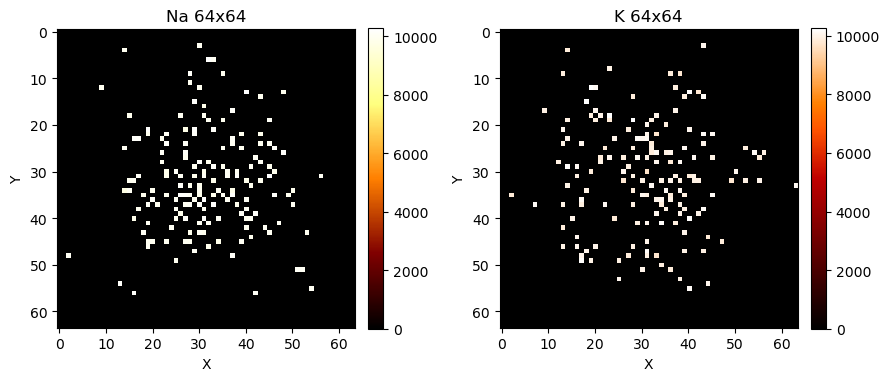

In [3118]:
# initialize lattice and images, then show lattices

# generate various coordinate systems:
x_nm_lattice = np.linspace(-lattice_size*lattice_constant/2.0, lattice_size*lattice_constant/2.0, lattice_size * pixels_per_site)
y_nm_lattice = np.linspace(-lattice_size*lattice_constant/2.0, lattice_size*lattice_constant/2.0, lattice_size * pixels_per_site)
X_nm_lattice, Y_nm_lattice = np.meshgrid(x_nm_lattice, y_nm_lattice) # this is float32

# psf space
x_nm_psf = np.linspace(-psf_kernel_size * lattice_constant/2.0, psf_kernel_size * lattice_constant/2.0, 2*(psf_kernel_size*pixels_per_site//2))
y_nm_psf = np.linspace(-psf_kernel_size * lattice_constant/2.0, psf_kernel_size * lattice_constant/2.0, 2*(psf_kernel_size*pixels_per_site//2))
X_nm_psf, Y_nm_psf = np.meshgrid(x_nm_psf, y_nm_psf) # this is float32

# generate lattices
lattice_Na = generate_gaussian_matrix(lattice_size, mean=(0,0), std_dev=Na_lattice_fractional_width, filling_fraction = filling_fraction_Na)
lattice_K  = generate_gaussian_matrix(lattice_size, mean=(0,0), std_dev=K_lattice_fractional_width, filling_fraction = filling_fraction_K)

# randomize fluoresence intensity
fluo_intensity_Na = np.random.poisson(typ_fluo_level_per_site, size=(lattice_size, lattice_size))* lattice_Na
fluo_intensity_K  = np.random.poisson(typ_fluo_level_per_site, size=(lattice_size, lattice_size))* lattice_K

# convert into real-space lattice
real_space_lattice_Na = np.zeros((len(x_nm_lattice), len(y_nm_lattice)))
real_space_lattice_K  = np.zeros((len(x_nm_lattice), len(y_nm_lattice)))

# generate Na lattice with small randomness of atom positions around the perfect location (~ pixels per site/8)
Na_locations_row = np.arange(pixels_per_site//2, real_space_lattice_Na.shape[0], pixels_per_site) 
Na_locations_row += np.random.randint(-lattice_location_jitter, lattice_location_jitter, size = len(Na_locations_row))
Na_locations_col = np.arange(pixels_per_site//2, real_space_lattice_Na.shape[1], pixels_per_site)
Na_locations_col += np.random.randint(-lattice_location_jitter, lattice_location_jitter, size = len(Na_locations_col))
real_space_lattice_Na[Na_locations_row[:,None], Na_locations_col] = np.multiply(lattice_Na,fluo_intensity_Na)

# generate K lattice with small randomness of atom positions around the perfect location (~ pixels per site/8)
K_locations_row = np.arange(pixels_per_site//2, real_space_lattice_K.shape[0], pixels_per_site) 
K_locations_row += np.random.randint(-lattice_location_jitter, lattice_location_jitter, size = len(K_locations_row))
K_locations_col = np.arange(pixels_per_site//2, real_space_lattice_K.shape[1], pixels_per_site)
K_locations_col += np.random.randint(-lattice_location_jitter, lattice_location_jitter, size = len(K_locations_col))
real_space_lattice_K[K_locations_row[:,None], K_locations_col] = np.multiply(lattice_K,fluo_intensity_K)

# generate PSF for each species
psf_Na = psf_2d(X_nm_psf, Y_nm_psf, NA=NA, lam=lam_Na)
psf_K  = psf_2d(X_nm_psf, Y_nm_psf, NA=NA, lam=lam_K)

# convolve this with real image (no noise) with python scipy fftconvolve (fast)
convolved_image_Na = scipy.signal.fftconvolve(real_space_lattice_Na, psf_Na, mode = 'same')
convolved_image_K  = scipy.signal.fftconvolve(real_space_lattice_K , psf_K , mode = 'same')

# generate shear and rotation of true lattice:
convolved_image_Na = rotate_image_openCV(convolved_image_Na, theta = Na_theta_rel, mode='relative')
convolved_image_Na = rotate_image_openCV(convolved_image_Na, theta = Na_theta_common, mode='common')
convolved_image_K  = rotate_image_openCV(convolved_image_K , theta = K_theta_rel, mode='relative')
convolved_image_K  = rotate_image_openCV(convolved_image_K , theta = K_theta_common, mode='common')

# generate noise and dark image for subtraction later
dark_image_Na = dark_BG(mu=muBG, sigma=sigmaBG, size=camera_ROI_size)
dark_image_K  = dark_BG(mu=muBG, sigma=sigmaBG, size=camera_ROI_size)
dark_image_Na_for_subtraction = dark_BG(mu=muBG, sigma=sigmaBG, size=camera_ROI_size)
dark_image_K_for_subtraction  = dark_BG(mu=muBG, sigma=sigmaBG, size=camera_ROI_size)

# generate camera images
camera_image_Na = skimage.transform.resize(convolved_image_Na,(camera_ROI_size,camera_ROI_size),mode='edge',anti_aliasing=False,preserve_range=True,order=0)
camera_image_with_noise_Na = (camera_image_Na + dark_image_Na - dark_image_Na_for_subtraction)

camera_image_K = skimage.transform.resize(convolved_image_K , (camera_ROI_size,camera_ROI_size),mode='edge',anti_aliasing=False,preserve_range=True,order=0)
camera_image_with_noise_K = camera_image_K + dark_image_K - dark_image_K_for_subtraction

# calculate SNR by taking the mean fluo intensity over the occupied sites / background signal
snr_Na = (typ_fluo_level_per_site - muBG) / (np.sqrt(typ_fluo_level_per_site) + sigmaBG)
snr_K  = (typ_fluo_level_per_site - muBG) / (np.sqrt(typ_fluo_level_per_site) + sigmaBG)

# show lattices
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))

# Na lattice
ax0 = ax[0].imshow(fluo_intensity_Na, cmap='afmhot') # can also do lattice_Na
ax[0].set_title(f'Na {lattice_size}x{lattice_size}')
ax[0].set_xlabel('X')
ax[0].set_ylabel('Y')
fig.colorbar(ax0, fraction=0.046, pad=0.04, ax=ax[0])

# K lattice
ax1 = ax[1].imshow(fluo_intensity_K, cmap='gist_heat') # can also do lattice_K
ax[1].set_title(f'K {lattice_size}x{lattice_size}')
ax[1].set_xlabel('X')
ax[1].set_ylabel('Y')
fig.colorbar(ax1, fraction=0.046, pad=0.04, ax=ax[1])
plt.tight_layout()
plt.show()

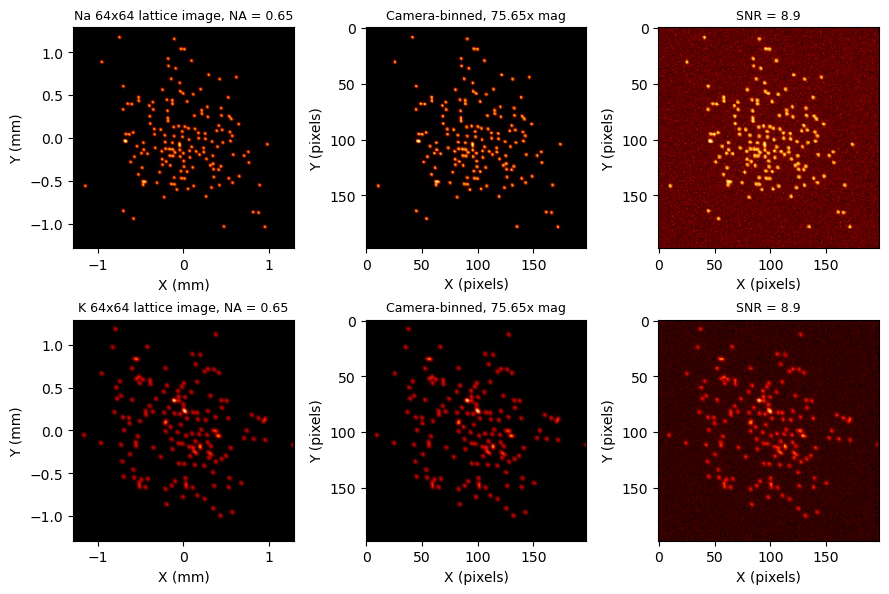

In [3119]:
# show true image to camera-binned to noisy
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(9, 6))
ax[0][0].imshow(convolved_image_Na, cmap='afmhot', extent = [x_nm_lattice[0]*imaging_magnification/1e6, x_nm_lattice[-1]*imaging_magnification/1e6, 
                                                               y_nm_lattice[0]*imaging_magnification/1e6, y_nm_lattice[-1]*imaging_magnification/1e6])
ax[0][0].set_title(f'Na {lattice_size}x{lattice_size} lattice image, NA = {NA}', fontsize = 9)
ax[0][0].set_xlabel('X (mm)')
ax[0][0].set_ylabel('Y (mm)')

ax[1][0].imshow(convolved_image_K, cmap='gist_heat',extent = [x_nm_lattice[0]*imaging_magnification/1e6, x_nm_lattice[-1]*imaging_magnification/1e6, 
                                                            y_nm_lattice[0]*imaging_magnification/1e6, y_nm_lattice[-1]*imaging_magnification/1e6])
ax[1][0].set_title(f'K {lattice_size}x{lattice_size} lattice image, NA = {NA}', fontsize = 9)
ax[1][0].set_xlabel('X (mm)')
ax[1][0].set_ylabel('Y (mm)')

ax01 = ax[0][1].imshow(camera_image_Na, cmap='afmhot')
ax[0][1].set_title(f'Camera-binned, {imaging_magnification}x mag', fontsize = 9)
ax[0][1].set_xlabel('X (pixels)')
ax[0][1].set_ylabel('Y (pixels)')

ax11 = ax[1][1].imshow(camera_image_K, cmap='gist_heat') 
ax[1][1].set_title(f'Camera-binned, {imaging_magnification}x mag', fontsize = 9)
ax[1][1].set_xlabel('X (pixels)')
ax[1][1].set_ylabel('Y (pixels)')

ax02 = ax[0][2].imshow(camera_image_with_noise_Na, cmap='afmhot') 
ax[0][2].set_title(f'SNR = {snr_Na:.1f}', fontsize = 9)
ax[0][2].set_xlabel('X (pixels)')
ax[0][2].set_ylabel('Y (pixels)')

ax12 = ax[1][2].imshow(camera_image_with_noise_K, cmap='gist_heat') 
ax[1][2].set_title(f'SNR = {snr_Na:.1f}', fontsize = 9)
ax[1][2].set_xlabel('X (pixels)')
ax[1][2].set_ylabel('Y (pixels)')      

plt.tight_layout()
plt.show()

Finding relative lattice angle: 100%|██████████| 100/100 [00:00<00:00, 808.02it/s]


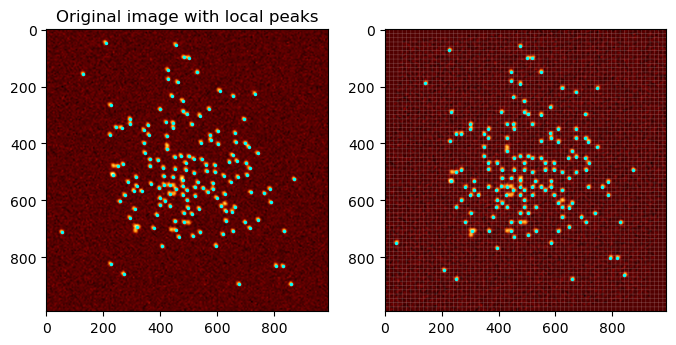

Optimizing image deconvolution: 100%|██████████| 10/10 [00:12<00:00,  1.21s/it]


Best common angle: 4.91 degrees
Best relative angle: 7.78 degrees


Finding relative lattice angle: 100%|██████████| 100/100 [00:00<00:00, 822.19it/s]


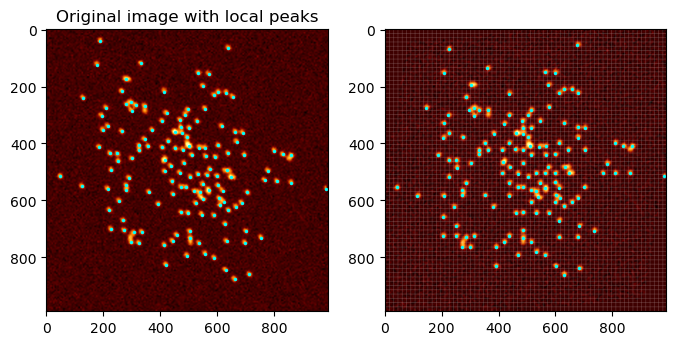

Optimizing image deconvolution: 100%|██████████| 20/20 [00:00<00:00, 29.90it/s]

Best common angle: 5.16 degrees
Best relative angle: 10.18 degrees
Elapsed time: 19.19 s


In [3296]:
# optimize deconvolution to generate best image
psf_Na_measured, psf_K_measured, imaging_magnification_guess = None, None, imaging_magnification
lattice_constant, camera_pixel_size = 532, 13
camera_pixel_per_site = imaging_magnification * lattice_constant * 1e-3 / camera_pixel_size 
eval_num_Na, eval_num_K = 10, 20
theta_common_guess_Na, theta_rel_guess_Na = 5.5,8
theta_common_guess_K, theta_rel_guess_K = 5.5,10
angle_search_window = 2.0 # degrees
minmass_Na, minmass_K = 15, 12

t = time.time()

Na_lattice_info, Na_wieners, Na_separations = optimize_deconvolution(camera_image_with_noise_Na, psf_Na_measured, eval_num_Na, 
                                                                     camera_pixel_per_site = camera_pixel_per_site, 
                                                                     lattice_constant = lattice_constant, lam = lam_Na, NA = NA, 
                                                                     phase_finding_mode = 'slow', 
                                                                     theta_common_guess = theta_common_guess_Na, 
                                                                     theta_rel_guess = theta_rel_guess_Na, 
                                                                     angle_search_window=angle_search_window,
                                                                     minmass = minmass_Na,
                                                                     show_peaks = True)

K_lattice_info, K_wieners, K_separations = optimize_deconvolution(camera_image_with_noise_K, psf_K_measured, eval_num_K, 
                                                                     camera_pixel_per_site = camera_pixel_per_site, 
                                                                     lattice_constant = lattice_constant, lam = lam_K, NA = NA, 
                                                                     phase_finding_mode = 'slow', 
                                                                     theta_common_guess = theta_common_guess_K, 
                                                                     theta_rel_guess = theta_rel_guess_K, 
                                                                     angle_search_window=angle_search_window,
                                                                     minmass = minmass_K,
                                                                     show_peaks = True)

print(f'Elapsed time: {time.time() - t:.2f} s')

# reconstruction report
# print('')
# reconstruction_matrix_Na, fidelity_Na, snr_Na_measured = lattice_reconstruction_report(Na_lattice_info, lattice_Na, print_result = True)
# reconstruction_matrix_K , fidelity_K, snr_K_measured  = lattice_reconstruction_report(K_lattice_info ,  lattice_K, print_result = True)

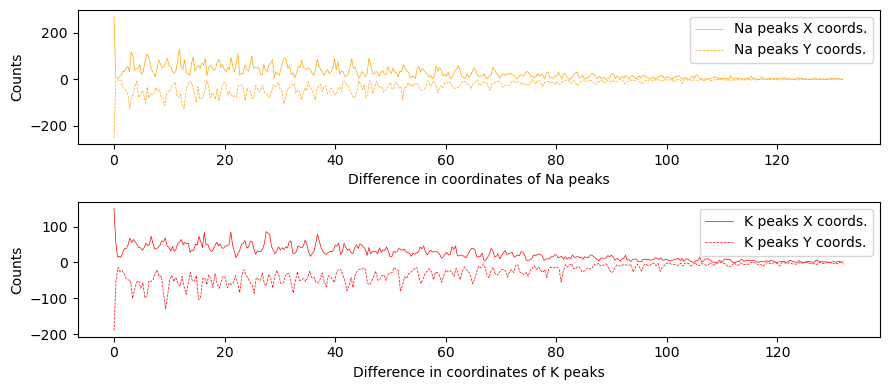

In [3297]:
# plot histograms of differences in the X- and Y- coordinates of peaks
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (9,4))
ax[0].plot(Na_lattice_info['diff_px_binned'], Na_lattice_info['diff_px_counts'], linewidth = 0.5, color = 'orange', label = 'Na peaks X coords.')
ax[0].plot(Na_lattice_info['diff_py_binned'], -Na_lattice_info['diff_py_counts'], '--', linewidth = 0.5, color = 'orange', label = 'Na peaks Y coords.')
ax[0].legend()
ax[1].plot(K_lattice_info['diff_px_binned'], K_lattice_info['diff_px_counts'], linewidth=0.5, color = 'red', label = 'K peaks X coords.')
ax[1].plot(K_lattice_info['diff_py_binned'], -K_lattice_info['diff_py_counts'], '--', linewidth = 0.5, color = 'red', label = 'K peaks Y coords.')
ax[1].legend()
ax[0].set_xlabel('Difference in coordinates of Na peaks')
ax[0].set_ylabel('Counts')
ax[1].set_xlabel('Difference in coordinates of K peaks')
ax[1].set_ylabel('Counts')

plt.tight_layout()
plt.show()

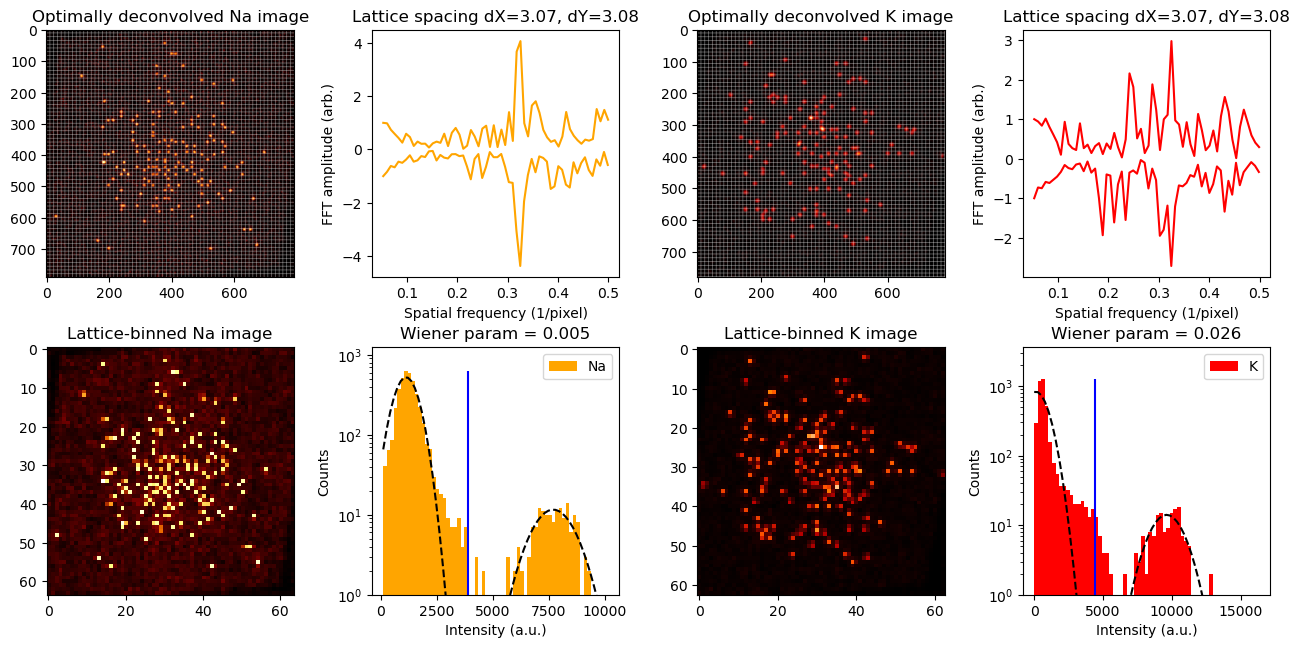

In [3298]:
# plot deconvolved image, lattice spacing, and occupation-thresholding histograms
fig, ax = plt.subplots(nrows=2, ncols=4, figsize = (13,6.5))

# ax[0][0].imshow(Na_lattice_info['best_cropped'], cmap = 'afmhot')
ax[0][0].imshow(draw_grid(Na_lattice_info['best_cropped'], line_space=round(Na_lattice_info['lattice_spacing_x'] )), cmap = 'afmhot')
ax[0][0].set_title('Optimally deconvolved Na image')
ax[0][1].plot(Na_lattice_info['freq_diff_px_counts'], Na_lattice_info['fdiff_px_counts'], color = 'orange')
ax[0][1].plot(Na_lattice_info['freq_diff_py_counts'], -Na_lattice_info['fdiff_py_counts'], color = 'orange')
ax[0][1].set_ylabel('FFT amplitude (arb.)')
ax[0][1].set_xlabel('Spatial frequency (1/pixel)')
ax[0][1].set_title(f'Lattice spacing dX={Na_lattice_info["lattice_spacing_x"]/Na_lattice_info["upscale_factor"]:.2f}, dY={Na_lattice_info["lattice_spacing_y"]/Na_lattice_info["upscale_factor"]:.2f}')
ax[0][1].set_box_aspect(1)
# ax[0][2].imshow(K_lattice_info['best_cropped'], cmap = 'gist_heat')
ax[0][2].imshow(draw_grid(K_lattice_info['best_cropped'], line_space=round(K_lattice_info['lattice_spacing_x'] )), cmap = 'gist_heat')
ax[0][2].set_title('Optimally deconvolved K image')
ax[0][3].plot(K_lattice_info['freq_diff_px_counts'], K_lattice_info['fdiff_px_counts'], color = 'red')
ax[0][3].plot(K_lattice_info['freq_diff_py_counts'], -K_lattice_info['fdiff_py_counts'], color = 'red')
ax[0][3].set_ylabel('FFT amplitude (arb.)')
ax[0][3].set_xlabel('Spatial frequency (1/pixel)')
ax[0][3].set_title(f'Lattice spacing dX={K_lattice_info["lattice_spacing_x"]/K_lattice_info["upscale_factor"]:.2f}, dY={K_lattice_info["lattice_spacing_y"]/K_lattice_info["upscale_factor"]:.2f}')
ax[0][3].set_box_aspect(1)

ax[1][0].imshow(Na_lattice_info['lattice_binned_image'], cmap = 'afmhot')
ax[1][0].set_title('Lattice-binned Na image')
ax[1][1].hist(Na_lattice_info['lattice_binned_image'].ravel(), 
           bins = round(np.sqrt(len(Na_lattice_info['lattice_binned_image'].ravel()))), color = 'orange', label = 'Na', log=True)
ax[1][1].plot(Na_lattice_info['intensities'], Na_lattice_info['best_fit'], '--', color = 'black')
ax[1][1].vlines(Na_lattice_info['threshold'], ymin=np.min(Na_lattice_info['occurrences']),ymax=np.max(Na_lattice_info['occurrences']), color = 'blue')
ax[1][1].set_xlabel('Intensity (a.u.)')
ax[1][1].set_ylabel('Counts')
ax[1][1].set_ylim(bottom=1)
ax[1][1].set_box_aspect(1)
ax[1][1].legend()
ax[1][1].set_title(f'Wiener param = {Na_lattice_info["wiener_param"]:.3f}')
ax[1][2].imshow(K_lattice_info['lattice_binned_image'], cmap = 'gist_heat')
ax[1][2].set_title('Lattice-binned K image')
ax[1][3].hist(K_lattice_info['lattice_binned_image'].ravel(), 
           bins = round(np.sqrt(len(K_lattice_info['lattice_binned_image'].ravel()))), color = 'red', label = 'K', log=True)
ax[1][3].plot(K_lattice_info['intensities'], K_lattice_info['best_fit'], '--', color = 'black')
ax[1][3].vlines(K_lattice_info['threshold'], ymin=np.min(K_lattice_info['occurrences']),ymax=np.max(K_lattice_info['occurrences']), color = 'blue')
ax[1][3].set_xlabel('Intensity (a.u.)')
ax[1][3].set_ylabel('Counts')
ax[1][3].set_ylim(bottom=1)
ax[1][3].set_box_aspect(1)
ax[1][3].legend()
ax[1][3].set_title(f'Wiener param = {K_lattice_info["wiener_param"]:.3f}')
plt.tight_layout()
plt.show()

# <font size = 5>Reconstructing Fermi2 lattice</font>

In [2563]:
# load data
# file_path = '/Users/huanbui/Desktop/Repositories/huanium/MIT_PhD/Fermi1/Fermi1 Calculator/Fermi2_test_images/08-15-2022_18_51_08.fits'
file_path = '/Users/huanbui/Desktop/Repositories/huanium/MIT_PhD/Fermi1/Fermi1 Calculator/Fermi2_test_images/08-23-2022_12_25_53.fits'

with fits.open(file_path) as hdul:   
    images_F2 = hdul[0].data

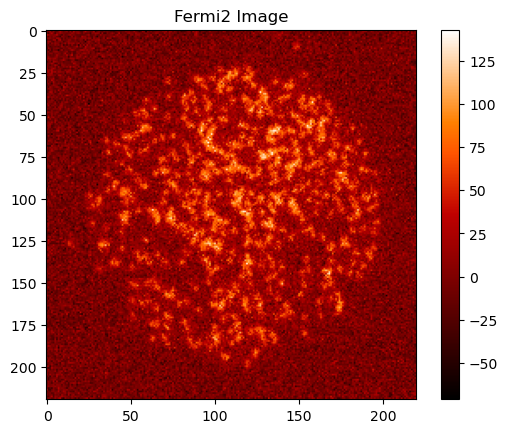

In [3128]:
image_index_F2 = 1
dark_index_F2 = 7
cropped_image_F2 = images_F2[image_index_F2][150:370, 140:360].astype(np.float32)
dark_cropped_image_F2 = images_F2[dark_index_F2][150:370, 140:360].astype(np.float32)
new_image_F2 = cropped_image_F2 - dark_cropped_image_F2

plt.imshow(new_image_F2, cmap='gist_heat')
plt.colorbar()
plt.title('Fermi2 Image')
plt.show()

In [3129]:
import pyfftw.interfaces.numpy_fft as fftw

def fermi_dirac_highpass_pyfftw(image, f_c=0.1, delta=0.02, n_threads=1):
    """
    Apply a Fermi–Dirac high-pass filter to a single image using pyFFTW for fast FFTs.
    
    Parameters:
      image            : 2D numpy array (input image)
      f_c              : cutoff frequency in cycles per pixel.
      delta            : transition width in frequency domain (cycles/pixel); smaller values produce a sharper cutoff.
      n_threads        : number of threads for pyFFTW.
      
    Returns:
      filtered_image   : 2D numpy array (the high-pass filtered image)
    """
    Ly, Lx = image.shape

    # Compute frequency coordinates for each dimension
    fx = np.fft.fftfreq(Lx, d=1)  # cycles per pixel along x
    fy = np.fft.fftfreq(Ly, d=1)  # cycles per pixel along y
    FX, FY = np.meshgrid(fx, fy)
    # Compute radial frequency (cycles per pixel)
    r = np.sqrt(FX**2 + FY**2)
    
    # Fermi–Dirac low-pass filter: H_LP(r) = 1/(1+exp((r - f_c)/delta))
    H_lp = 1.0 / (1.0 + np.exp((r - f_c) / delta))
    # High-pass filter is 1 - low-pass filter:
    H_hp = 1.0 - H_lp

    # Apply the high-pass filter in Fourier space
    image_fft = fftw.fft2(image, threads=n_threads)
    filtered_fft = image_fft * H_hp
    filtered_image = fftw.ifft2(filtered_fft, s=image.shape, threads=n_threads)
    filtered_image = np.real(filtered_image)
    
    return filtered_image

def fermi_dirac_lowpass_pyfftw(image, f_c=0.1, delta=0.02, n_threads=1):
    """
    Apply a Fermi–Dirac low-pass filter to a single image using pyFFTW for fast FFTs.
    
    Parameters:
      image            : 2D numpy array (input image)
      f_c              : cutoff frequency in cycles per pixel.
      delta            : transition width in frequency domain (cycles/pixel); smaller values produce a sharper cutoff.
      n_threads        : number of threads for pyFFTW.
      
    Returns:
      filtered_image   : 2D numpy array (the low-pass filtered image)
    """
    Ly, Lx = image.shape

    # Compute frequency coordinates for each dimension
    fx = np.fft.fftfreq(Lx, d=1)  # cycles per pixel along x
    fy = np.fft.fftfreq(Ly, d=1)  # cycles per pixel along y
    FX, FY = np.meshgrid(fx, fy)
    # Compute radial frequency (cycles per pixel)
    r = np.sqrt(FX**2 + FY**2)
    
    # Fermi–Dirac low-pass filter: H_LP(r) = 1/(1+exp((r - f_c)/delta))
    H_lp = 1.0 / (1.0 + np.exp((r - f_c) / delta))

    # Apply the low-pass filter in Fourier space
    image_fft = fftw.fft2(image, threads=n_threads)
    filtered_fft = image_fft * H_lp
    filtered_image = fftw.ifft2(filtered_fft, s=image.shape, threads=n_threads)
    filtered_image = np.real(filtered_image)
    
    return filtered_image

In [3161]:
# get peaks using trackpy:
super_sample_factor = 7
camera_pixel_per_site = 3
filtered_image_F2_upscaled = cv2.resize(new_image_F2, (new_image_F2.shape[1]*super_sample_factor, new_image_F2.shape[0]*super_sample_factor), 
                   interpolation = cv2.INTER_NEAREST)
filtered_image_F2_upscaled = fermi_dirac_lowpass_pyfftw(filtered_image_F2_upscaled, f_c=0.2/super_sample_factor, delta=0.01, n_threads=4)

In [3166]:
# find peaks using trackpy_locate:
peaks = tp.locate(filtered_image_F2_upscaled/filtered_image_F2_upscaled.max(), 
                    diameter = round(super_sample_factor*camera_pixel_per_site/2)*2 + 1, 
                    minmass = 9,
                    separation = round(super_sample_factor*camera_pixel_per_site/2)*2 + 1,
                    maxsize = round(super_sample_factor*camera_pixel_per_site/2)*2 + 1)

peaks = np.column_stack((peaks['y'], peaks['x']))

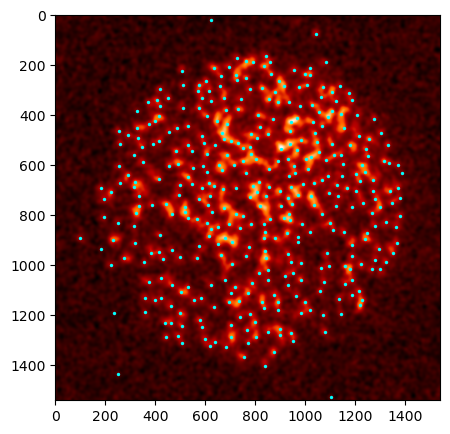

In [3167]:
# show image with peaks:
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(filtered_image_F2_upscaled, cmap='gist_heat')
ax.scatter(peaks[:, 1], peaks[:, 0], s=2, c='cyan', label='Detected Peaks')
plt.show()

In [3173]:
new_peaks = rotate_peak(peaks, theta = 42.8, center_coords= [filtered_image_F2_upscaled.shape[0]//2, filtered_image_F2_upscaled.shape[1]//2],mode = 'common' )
new_peaks = rotate_peak(new_peaks, theta = -2.8, center_coords= [filtered_image_F2_upscaled.shape[0]//2, filtered_image_F2_upscaled.shape[1]//2],mode = 'relative' )

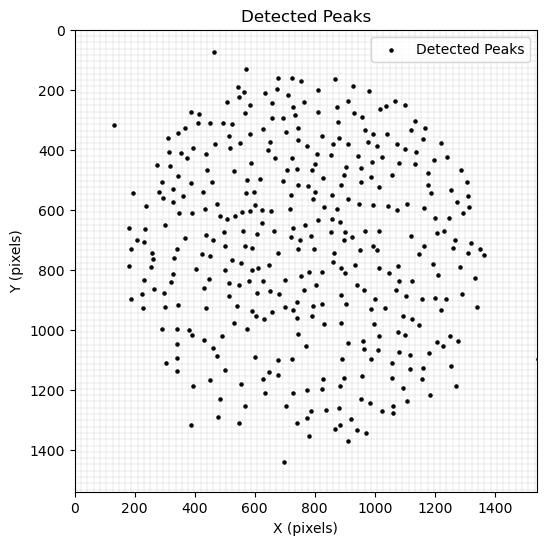

In [3174]:
# show image with peaks:
fig, ax = plt.subplots(figsize=(6, 6))
# draw grid:
# ax.imshow(draw_grid(filtered_image_F2_upscaled, line_space= super_sample_factor * camera_pixel_per_site), cmap='afmhot')
# ax.imshow(filtered_image_F2_upscaled, cmap='gist_heat')
ax.scatter(new_peaks[:, 1], new_peaks[:, 0], s=5, c='black', label='Detected Peaks')
# add grid lines spaced 3 pixels apart
ax.set_xlim(0, filtered_image_F2_upscaled.shape[1])
ax.set_ylim(filtered_image_F2_upscaled.shape[0], 0)
ax.set_title('Detected Peaks')
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.legend()
ax.set_box_aspect(1)
for i in range(0, filtered_image_F2_upscaled.shape[1], camera_pixel_per_site * super_sample_factor):
    ax.axvline(x=i, color='gray', linestyle='--', linewidth=0.15)
for i in range(0, filtered_image_F2_upscaled.shape[0], camera_pixel_per_site * super_sample_factor):
    ax.axhline(y=i, color='gray', linestyle='--', linewidth=0.15)
plt.show()

In [3175]:
diff_px, diff_py = compute_differences(new_peaks[:,0]) / super_sample_factor, compute_differences(new_peaks[:,1]) / super_sample_factor

# generate histograms, takes around 15 ms
diff_px_counts, diff_px_binned = numba_histogram(diff_px, bins = round(2*np.sqrt(len(diff_px))))
diff_py_counts, diff_py_binned = numba_histogram(diff_py, bins = round(2*np.sqrt(len(diff_py))))
fdiff_px_counts, freq_diff_px_counts = FT_no_DC(signal = diff_px_counts, bin_size = diff_px_binned[1] - diff_px_binned[0]) 
fdiff_py_counts, freq_diff_py_counts = FT_no_DC(signal = diff_py_counts, bin_size = diff_py_binned[1] - diff_py_binned[0]) 

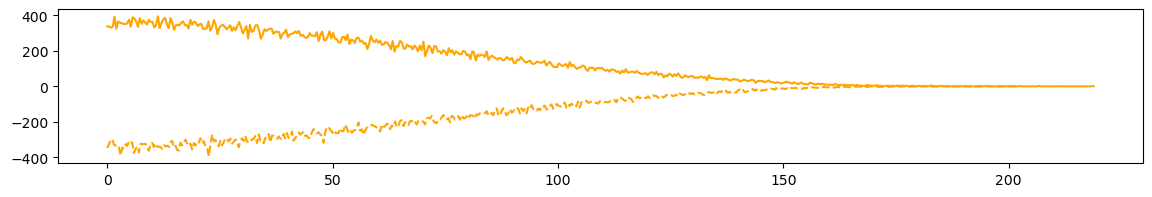

In [3176]:
fig, ax = plt.subplots(figsize=(14, 2))
plt.plot(diff_px_binned, diff_px_counts, color = 'orange', label = 'X coords.')
plt.plot(diff_py_binned, -diff_py_counts, '--', color = 'orange', label = 'Y coords.')
plt.show()

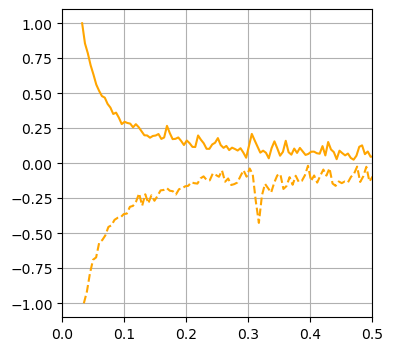

In [3177]:
fig, ax = plt.subplots(figsize=(4, 4))
plt.plot(freq_diff_px_counts, fdiff_px_counts, color = 'orange', label = 'X coords.')
plt.plot(freq_diff_py_counts, -fdiff_py_counts, '--', color = 'orange', label = 'Y coords.')
plt.xlim([0,0.5])
plt.grid()
plt.show()

# <font size = 5>Reconstructing Fermi3 lattice</font>

In [5]:
import h5py

# Replace 'file_path' with the path to your HDF5 file
file_path = '/Users/huanbui/Desktop/Repositories/huanium/MIT_PhD/Fermi1/Fermi1 Calculator/Fermi3_test_images/Fermi1102_state1.hdf5'
data_FL2 = None
data_FL3 = None

# Open the HDF5 file
with h5py.File(file_path, 'r') as hdf:
    data_FL2 = np.array(hdf['FL2'][:], dtype = np.float64)
    data_FL3 = np.array(hdf['FL3'][:], dtype = np.float64)

In [47]:
print(data_FL2.shape)

(201, 512, 512)


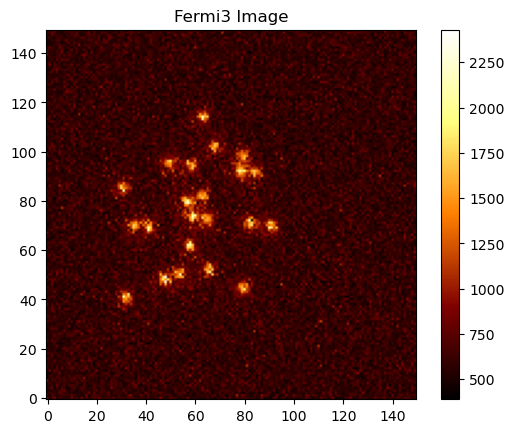

In [45]:
full_region = data_FL2[6][150:300, 150:300]
plt.imshow(full_region, cmap='afmhot', origin = 'lower')
plt.colorbar()
plt.title('Fermi3 Image')
plt.show()

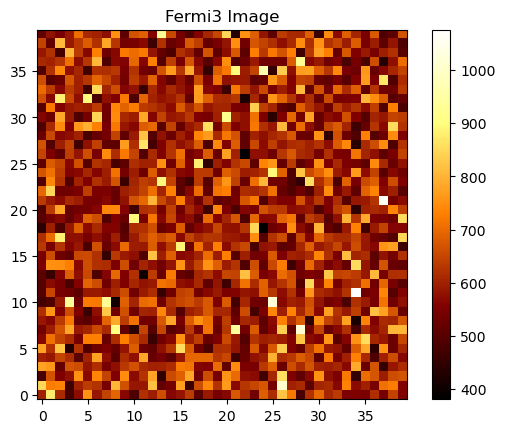

(array([  2.,   3.,   4.,  10.,  22.,  30.,  69.,  78., 116., 124., 143.,
        123., 128., 144., 100.,  80.,  76.,  69.,  47.,  40.,  45.,  39.,
         23.,  14.,  15.,  11.,  11.,   9.,   6.,   6.,   2.,   3.,   2.,
          1.,   0.,   1.,   2.,   0.,   0.,   2.]),
 array([ 381.   ,  398.375,  415.75 ,  433.125,  450.5  ,  467.875,
         485.25 ,  502.625,  520.   ,  537.375,  554.75 ,  572.125,
         589.5  ,  606.875,  624.25 ,  641.625,  659.   ,  676.375,
         693.75 ,  711.125,  728.5  ,  745.875,  763.25 ,  780.625,
         798.   ,  815.375,  832.75 ,  850.125,  867.5  ,  884.875,
         902.25 ,  919.625,  937.   ,  954.375,  971.75 ,  989.125,
        1006.5  , 1023.875, 1041.25 , 1058.625, 1076.   ]),
 <BarContainer object of 40 artists>)

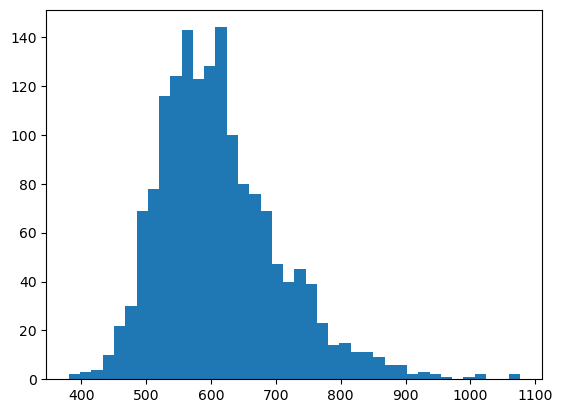

In [32]:
corner_region = data_FL2[3][150:190, 150:190]
plt.imshow(corner_region, cmap='afmhot', origin = 'lower')
plt.colorbar()
plt.title('Fermi3 Image')
plt.show()

plt.hist(corner_region.ravel(), bins = int(np.sqrt( len( corner_region.ravel() )  )  )  )


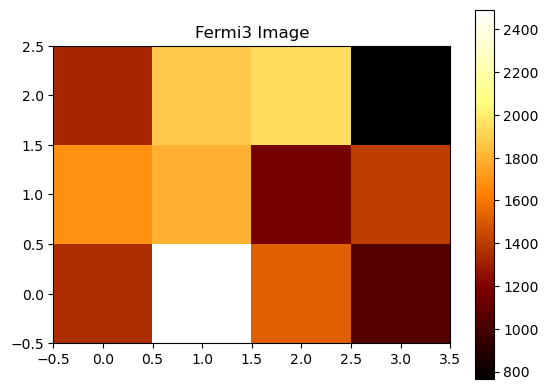

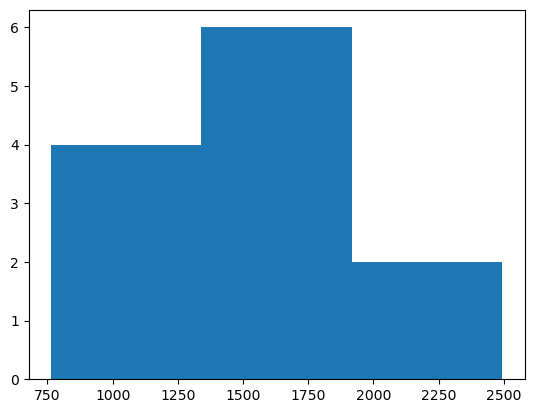

In [38]:
site_region = data_FL2[3][212:215, 192:196]
plt.imshow(site_region, cmap='afmhot', origin = 'lower')
plt.colorbar()
plt.title('Fermi3 Image')
plt.show()

plt.hist(site_region.ravel(), bins = int(np.sqrt( len( site_region.ravel() )  )  )  )
plt.show()

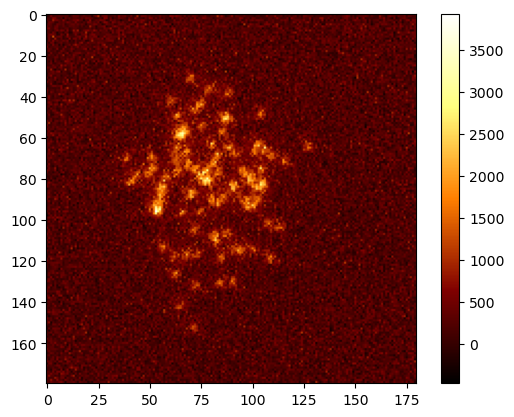

In [3287]:
cropped_image_F3 = np.copy(data_FL2[:][0][150:330,140:320])
for i in range(10,14):
  cropped_image_F3 += data_FL2[:][i][150:330,140:320] - 700
plt.imshow(cropped_image_F3, cmap = 'afmhot')
plt.colorbar()
plt.show()

In [3290]:
# Fermi-Dirac filter image before deconvolution:

In [ ]:
# roughly deconvole image first (not optimal), then analyze for spacing and angles:
camera_pixel_per_site = 3
psf_F3_measured = None

deconvolved_F3_image = wiener(cropped_image_F3, conj_F_psf, abs_F_psf_squared, 0.03).astype(np.float32) 

Finding relative lattice angle: 100%|██████████| 100/100 [00:00<00:00, 870.51it/s]


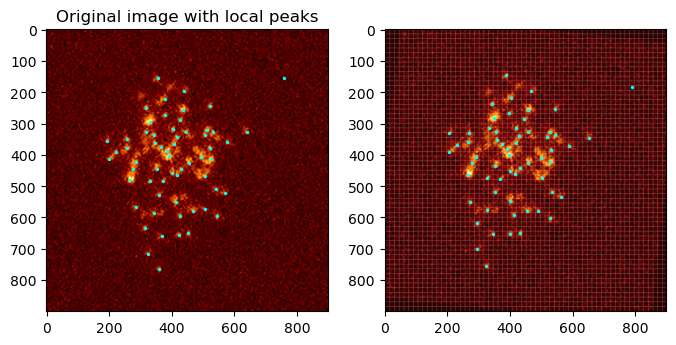

-5.5353537 0.8989899


In [3288]:
[best_theta_common, best_theta_rel], spacing_dict, rectified_image = find_lattice_spacing_and_angles(cropped_image_F3,
                                                                                                    camera_pixel_per_site = 3, 
                                                                                                    theta_common_guess = -6.0, 
                                                                                                    theta_rel_guess = 1,
                                                                                                    angle_search_window=2.0,
                                                                                                    plotting = True,
                                                                                                    minmass = 8)

print(best_theta_common, best_theta_rel)

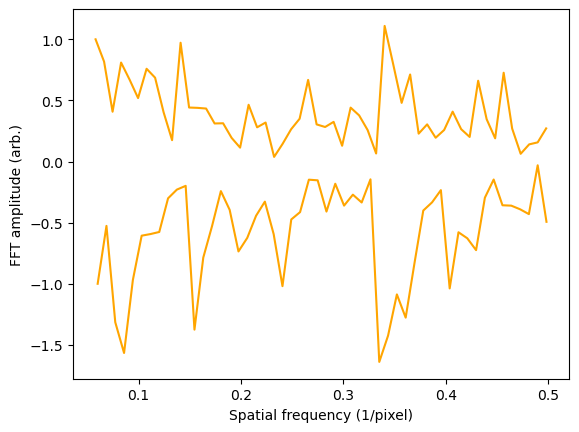

In [3289]:
plt.plot(spacing_dict['freq_diff_px_counts'], spacing_dict['fdiff_px_counts'], color = 'orange')
plt.plot(spacing_dict['freq_diff_py_counts'], -spacing_dict['fdiff_py_counts'], color = 'orange')
plt.ylabel('FFT amplitude (arb.)')
plt.xlabel('Spatial frequency (1/pixel)')
plt.show()

# <font size = 5>To do</font>

# <font size = 5>MOT Air slide table test</font>

In [5]:
# read csv files
path_fiber = "/Users/huanbui/Desktop/air stage test/20250228_FIBER.csv" # sample rate = 16.7 kS/s
path_PD = "/Users/huanbui/Desktop/air stage test/20250228_QUADRANT_PD.csv" # sample rate = 1.67 kS/s
df_fiber = pd.read_csv(path_fiber)
df_PD = pd.read_csv(path_PD)
# remove the first row and convert to float
df_fiber = df_fiber.drop(0)
df_fiber = df_fiber.astype(float)
df_PD = df_PD.drop(0)

In [6]:
# pickle df to hopefully load it faster next time:
df_fiber.to_pickle('/Users/huanbui/Desktop/air stage test/df_fiber.pkl')
df_PD.to_pickle('/Users/huanbui/Desktop/air stage test/df_PD.pkl')

In [45]:
PD_PD_prep = pd.to_numeric(df_PD['Channel X'], errors='coerce')

In [9]:
df_PD

,Time,Channel X,Channel sum,Channel trigger,(X)/(sum)
1,0.00000000,-0.63624710,3.63752900,0.02136491,-134.03150000
2,0.00060000,-0.59406660,3.65202700,0.03265779,-117.50990000
3,0.00120000,-0.60108660,3.58274300,0.02716396,-96.50259000
4,0.00180000,-0.59754610,3.87422200,0.02136491,-76.96320000
5,0.00240000,-0.55188620,3.64042900,0.02136491,-59.27031000
...,...,...,...,...,...
78769800,47372.683254,0.01489440,0.520236,4.4848,28.63010000
78769801,47372.683854,0.01373459,0.520236,4.496093,26.69831000
78769802,47372.684454,0.01373459,0.520236,4.496093,25.96653000
78769803,47372.685054,0.01489440,0.520236,4.496093,28.63010000


In [276]:
# sample rate = 16.7 kS/s for fiber and 1.67 kS/s for PD
sample_rate_fiber = int(16.7e3)
sample_rate_PD = int(1.67e3)

# try analyzing the first few seconds of data
duration = 4500 # 4500s max for fiber data, ???s max for PD data
start = int(sample_rate_fiber * 4)
end = int(duration * sample_rate_fiber) + start
t = df_fiber['Time'].values[start:end]
PD = df_fiber['Channel X'].values[start:end]
sum = df_fiber['Channel sum'].values[start:end]
trig = df_fiber['Channel trigger'].values[start:end]
length = df_fiber.shape[0]
cutoff = 0.1

# analyze PD data:
duration_PD = 47000
start_PD = int(sample_rate_PD * 7.0)
end_PD = int(duration_PD * sample_rate_PD) + start_PD
t_PD = df_PD['Time'].values[start_PD:end_PD].astype(float)
PD_PD = PD_PD_prep[start_PD:end_PD].astype(float)
sum_PD = df_PD['Channel sum'].values[start_PD:end_PD].astype(float)
trig_PD = df_PD['Channel trigger'].values[start_PD:end_PD].astype(float)
length_PD = df_PD.shape[0]
cutoff_PD = 0.5

In [211]:
# generate trig window for PD:
@jit(nopython=True)
def generate_trig_window_for_PD(t, trig, delay, integration_window):
    i_start_list = []
    trig_window_for_PD = np.zeros(len(t))
    for i in range(1,len(t)):
        if trig[i-1] > 0.5 and trig[i] < 0.5:
            i_start = i
            i_start_list.append(i)
        if i > i_start+delay and i < i_start + delay + integration_window:
            trig_window_for_PD[i] = 1
    return i_start_list, trig_window_for_PD

In [277]:
# choose which dataset to analyze:
data_set = 'fiber' # 'fiber' 'PD'

if data_set == 'PD':
    t = t_PD
    PD = PD_PD
    sum = sum_PD
    trig = trig_PD
    sample_rate = sample_rate_PD
    cutoff = cutoff_PD
    duration = duration_PD
    length = df_PD.shape[0]
else:
    length = df_fiber.shape[0]
    sample_rate = sample_rate_fiber

# generate integration windows
i_start = 0
delay = int(sample_rate * 1.6)
integration_window = int(sample_rate * 2.65)
i_start_list, trig_window_for_PD = generate_trig_window_for_PD(t, trig, delay, integration_window)
# generate averages and std per cycle 
signal_averages = []
signal_std = []
normalized_signal = []
normalized_signal_std = []
new_i_start_list = []
# need to parallelize this
for i in i_start_list:
    m = np.mean(PD[i+delay:i+delay+integration_window])
    if m > cutoff:
        signal_averages.append(m)
        signal_std.append(np.std(PD[i+delay:i+delay+integration_window]))
        normalized_signal.append(np.mean(PD[i+delay:i+delay+integration_window] / (sum[i+delay:i+delay+integration_window]-0.0))) # 0.55 for PD
        normalized_signal_std.append(np.std(PD[i+delay:i+delay+integration_window] / (sum[i+delay:i+delay+integration_window]-0.0))) # 0.55 for PD
        new_i_start_list.append(i)

i_start_list = new_i_start_list
signal_averages = np.array(signal_averages)
signal_std = np.array(signal_std)
normalized_signal = np.array(normalized_signal)
normalized_signal_std = np.array(normalized_signal_std)

print(f'Analyzed {100 * duration*sample_rate/length:.2f}% of {data_set} data')

Analyzed 99.91% of fiber data


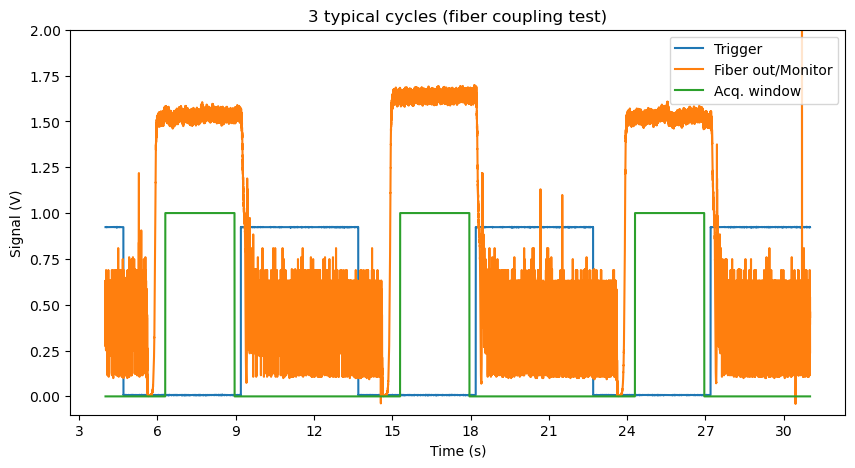

In [298]:
# plot typical cycles
end_point = 450000
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,5))
ax.plot(t[:end_point:5], trig[:end_point:5]/np.max(trig), label='Trigger')
ax.plot(t[:end_point:5], PD[:end_point:5]/sum[:end_point:5], label='Fiber out/Monitor')
# ax.plot(t[:end_point:5], sum[:end_point:5], label='Total')
ax.plot(t[:end_point:5], trig_window_for_PD[:end_point:5], label='Acq. window')


ax.set_xlabel('Time (s)')
ax.set_ylabel('Signal (V)')
ax.legend()

# make ticks in seconds
ax.xaxis.set_major_locator(plt.MaxNLocator(10))
ax.yaxis.set_major_locator(plt.MaxNLocator(10))

ax.set_title('3 typical cycles (fiber coupling test)')
ax.set_ylim([-0.1, 2.0])
plt.show()

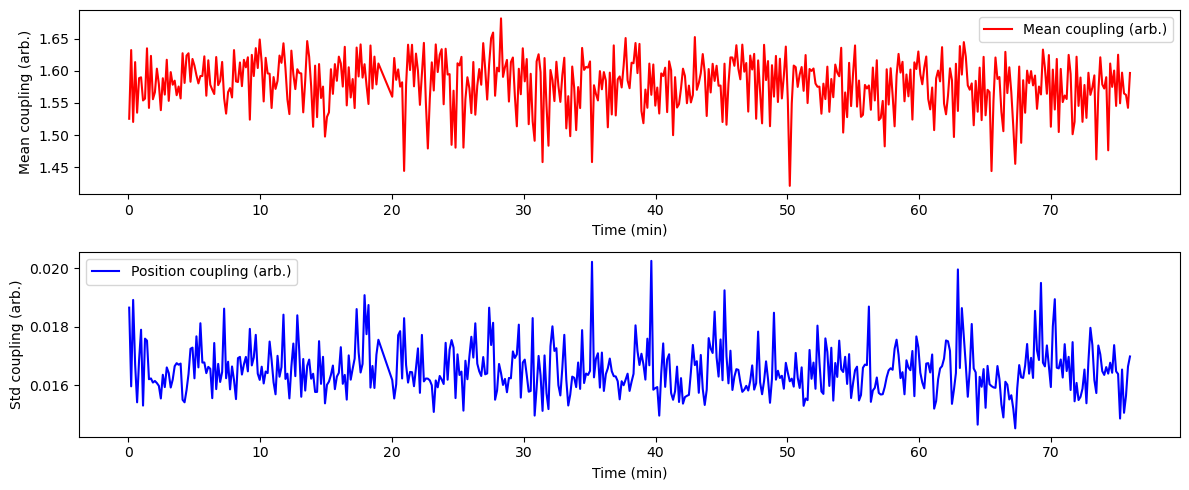

In [294]:
# plot
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12,5))
ax[0].plot(t[i_start_list]/60, normalized_signal, label='Mean coupling (arb.)', color = 'red')
ax[0].set_xlabel('Time (min)')
ax[0].set_ylabel('Mean coupling (arb.)')
ax[0].legend()
ax[1].plot(t[i_start_list]/60, normalized_signal_std, label='Position coupling (arb.)', color = 'blue')
ax[1].set_xlabel('Time (min)')
ax[1].set_ylabel('Std coupling (arb.)')
ax[1].legend()
plt.tight_layout()
plt.show()

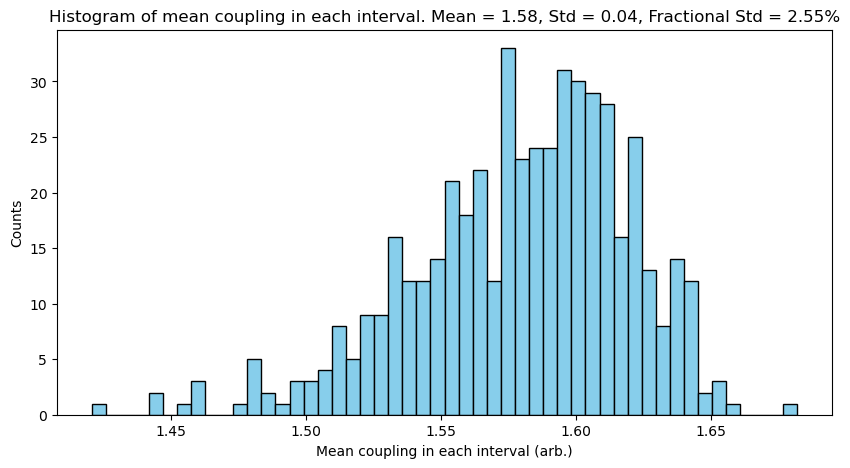

In [299]:
# plot histograms:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,5))
ax.hist(normalized_signal, bins=50, color='skyblue', edgecolor='black')
ax.set_xlabel('Mean coupling in each interval (arb.)')
ax.set_ylabel('Counts')

# get statistics for the inteval means:
mean_normalized_signal = np.mean(normalized_signal)
std_normalized_signal = np.std(normalized_signal)
ax.set_title(f'Histogram of mean coupling in each interval. Mean = {mean_normalized_signal:.2f}, Std = {std_normalized_signal:.2f}, Fractional Std = {100 * std_normalized_signal/mean_normalized_signal:.2f}%')

plt.show()

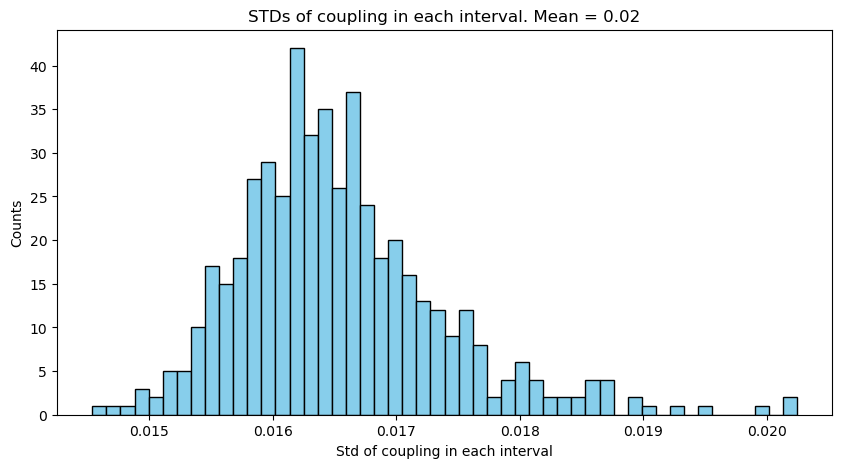

In [302]:
# plot histogram of std of efficiencies:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,5))
ax.hist(normalized_signal_std, bins=50, color='skyblue', edgecolor='black')
ax.set_xlabel('Std of coupling in each interval')
ax.set_ylabel('Counts')
mean_normalized_signal_std = np.mean(normalized_signal_std)
ax.set_title(f'STDs of coupling in each interval. Mean = {mean_normalized_signal_std:.2f}')
plt.show()

In [196]:
# distance conversion for fiber is 400 um to reduce fiber coupling efficiency by 50%
400 * 2.5/50

20.0

In [207]:
# quadrant PD fluctuation, long-term
10 * (0.003/4.0) * 1e3 # in um


7.5

In [209]:
0.016 * 10 * (0.28/4.0) * 1e3 # in um

11.200000000000001

# <font size = 5>Vacuum logging</font>

In [89]:
# read the Vacuum_log.csv file from "Downloads" folder and plot the pressure vs time:
import pandas as pd
import matplotlib.pyplot as plt
file_path = '/Users/huanbui/Downloads/Vacuum_log.csv'
file_path_2024 = '/Users/huanbui/Downloads/Vacuum_Log-2024-03-25.csv'
file_path_2026 = '/Users/huanbui/Downloads/Vacuum_Log-2026-01-12.csv'
df_vacuum = pd.read_csv(file_path)
df_vacuum_2024 = pd.read_csv(file_path_2024)
df_vacuum_2026 = pd.read_csv(file_path_2026)
df = df_vacuum_2026

In [90]:
df_vacuum.columns

Index(['NA_OVEN_PUMP pressure', 'K_INTERMEDIATE_PUMP pressure',
       'MAIN(1)_AND_NA_INTERMEDIATE(2)_Pump pressure2', 'Time',
       'K_OVEN_PUMP pressure',
       'MAIN(1)_AND_NA_INTERMEDIATE(2)_Pump pressure1'],
      dtype='object')

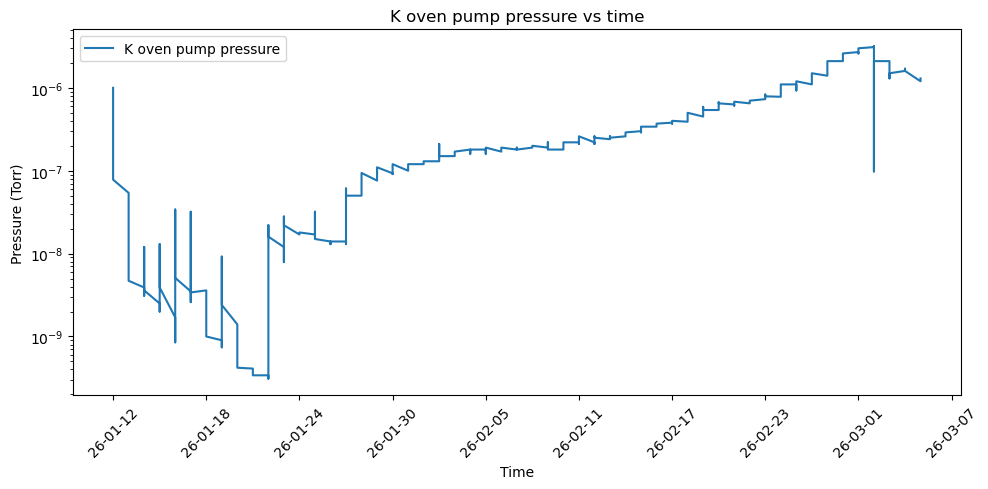

In [110]:
# plot the K_OVEN_PUMP pressure vs time. Plot one every 5000 points to reduce the number of points plotted:
fig, ax = plt.subplots(figsize=(10,5))
times = df['Time'][::210].str.split().str[0]
# ignore non-numeric characters in the pressure column and convert to float:
df['K_OVEN_PUMP pressure'] = pd.to_numeric(df['K_OVEN_PUMP pressure'], errors='coerce')
pressues = df['K_OVEN_PUMP pressure'][::210]
ax.plot(times, pressues, label='K oven pump pressure')
ax.set_xlabel('Time')
ax.set_ylabel('Pressure (Torr)')
ax.set_title('K oven pump pressure vs time')
ax.xaxis.set_major_locator(plt.MaxNLocator(10))
ax.legend()
# ax.set_ylim([None, 1e-4])
# set y to log scale:
ax.set_yscale('log')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

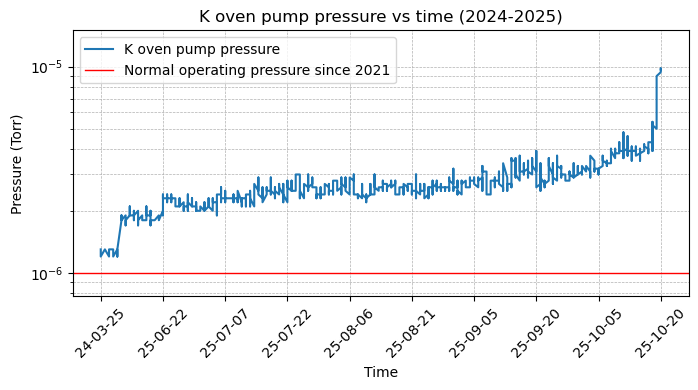

In [88]:
# plot the K_OVEN_PUMP pressure vs time, ignoring non-numeric values. Plot one every 5000 points to reduce the number of points plotted:
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(df_vacuum_2024['Time'][::100].str.split().str[0], pd.to_numeric(df_vacuum_2024['K_OVEN_PUMP pressure'], errors='coerce')[::100], label='K oven pump pressure')
ax.set_xlabel('Time')
ax.set_ylabel('Pressure (Torr)')
ax.set_title('K oven pump pressure vs time (2024-2025)', fontsize = 12)
ax.xaxis.set_major_locator(plt.MaxNLocator(10))
ax.legend()
# add a horizontal line, colored red, at 1e-6 Torr:
ax.axhline(y=1e-6, color='red', linestyle='-', linewidth=1.0, label='Normal operating pressure since 2021')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylim([None, 1.5e-5])
plt.yscale('log')
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.show()

# <font size = 5>RGA traces</font>

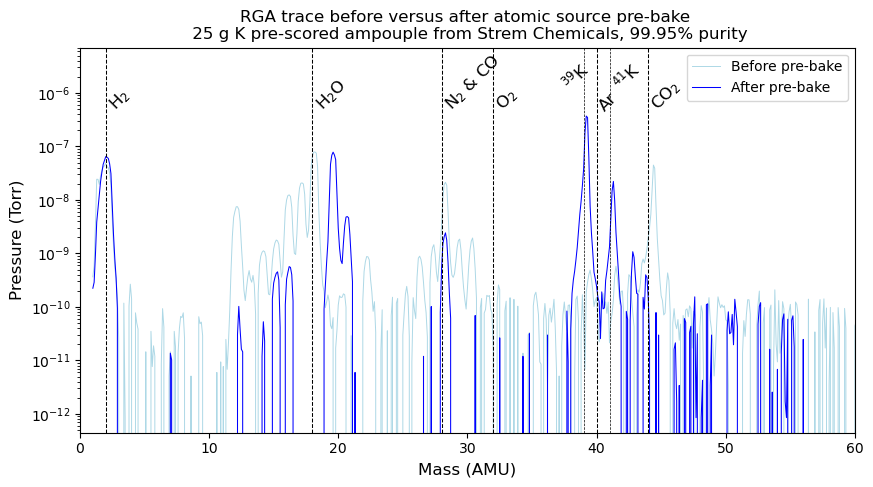

In [5]:
# Pre-bake partial pressures in Torr
#  read .txt file and read off the pressure column on the second column, ignoring the first 28 rows:
file_path_post = '/Users/huanbui/Desktop/HQB_thesis_figures/RGA traces/AfterPreBake_0651PM.csv'
df_rga_post = pd.read_csv(file_path_post, skiprows=28)
amu = df_rga_post['              Mass (AMU)'].values
after_bake_pressures_torr = df_rga_post['         Intensity (Torr)'].values

# post pre-bake partial pressures in Torr
file_path_pre = '/Users/huanbui/Desktop/HQB_thesis_figures/RGA traces/BeforePreBake_Analog-20260310-100729-622.csv'
df_rga_pre = pd.read_csv(file_path_pre, skiprows=28)
before_bake_pressures_torr = df_rga_pre['         Intensity (Torr)'].values

# set plot font:
# plt.rcParams["font.family"] = "serif" # Can be 'sans-serif', 'serif', 'monospace', etc.
# plt.rcParams["font.serif"] = ["DejaVu Serif"]
# ["Times New Roman"] # Specify the desired font name

# plot the RGA trace:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(amu, before_bake_pressures_torr, label='Before pre-bake', color = 'lightblue', linewidth = 0.7)
ax.plot(amu, after_bake_pressures_torr, label='After pre-bake', color = 'blue', linewidth = 0.75)
ax.set_xlabel('Mass (AMU)', fontsize = 12)
ax.set_ylabel('Pressure (Torr)', fontsize=12)
ax.set_title('RGA trace before versus after atomic source pre-bake \n 25 g K pre-scored ampouple from Strem Chemicals, 99.95% purity', fontsize = 12)
ax.set_yscale('log')
ax.set_ylim([None, 7e-6])
ax.set_xlim([0, 60])

# add vertical lines for common contaminants:
contaminants = {r'H$_2$': 2, r'H$_2$O': 18, r'N$_2$ & CO': 28, r'O$_2$': 32, r'CO$_2$': 44, r'Ar':40}
for name, mass in contaminants.items():
    ax.axvline(x=mass, color='black', linestyle='--', linewidth=0.75)
    ax.text(mass, 4.0e-7, name, rotation=45, verticalalignment='bottom', fontsize=12)
potassium_isotopes = {r'$^{39}$K': 39, r'$^{41}$K': 41}
# K39
ax.axvline(x=39, color='black', linestyle='--', linewidth=0.5)
ax.text(39-2, 1e-6, r'$^{39}$K', rotation=45, verticalalignment='bottom', fontsize=12, color='black')
# K41
ax.axvline(x=41, color='black', linestyle='--', linewidth=0.5)
ax.text(41, 1e-6, r'$^{41}$K', rotation=45, verticalalignment='bottom', fontsize=12, color='black')
ax.legend()
# plt.grid()
plt.show()

# <font size = 5>IPG RIN Measurement</font>

In [33]:
# read .csv file with RIN measurement and plot noise density versus frequency:
# file_path_rin = '/Users/huanbui/Desktop/HQB_thesis_figures/IPG RIN/ipg74w_0thorder_1.98V.csv'
file_path_rin = '/Users/huanbui/Desktop/HQB_thesis_figures/IPG RIN/ipg30w_locked_maxPI_366mVDC.csv'
df_rin = pd.read_csv(file_path_rin, skiprows=6)
df_rin.columns
frequency = df_rin['Frequency (Hz)'].values
rin_density = df_rin[' RIN (dBc / Hz)'].values
integrated_rin = df_rin['Integrated RIN (%RMS)'].values

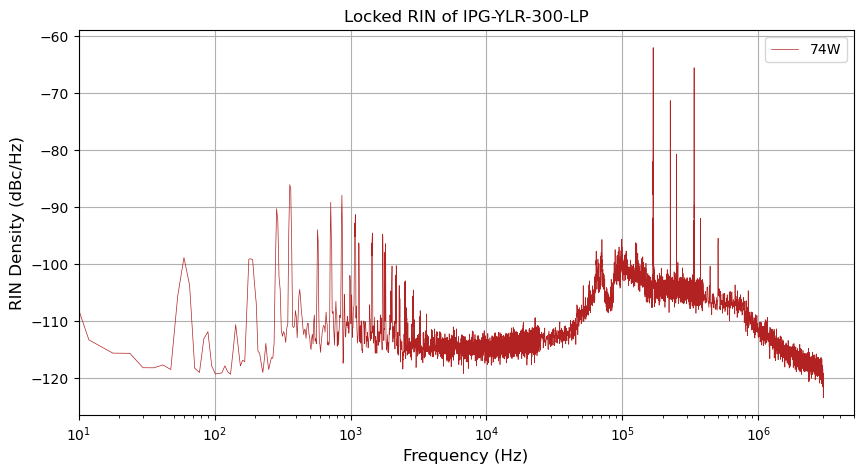

In [57]:
# plot RIN density versus frequency:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(frequency, rin_density, color = 'firebrick', linewidth=0.5, label = '74W')
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('RIN Density (dBc/Hz)', fontsize=12)
ax.set_title('Locked RIN of IPG-YLR-300-LP', fontsize=12)
ax.set_xscale('log')
# ax.set_ylim([-150, -50])
ax.set_xlim([10, 5e6])
ax.legend()
plt.grid()
plt.show()